In [5]:
import os
import gc
import math
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, matthews_corrcoef,
    cohen_kappa_score, brier_score_loss, precision_recall_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision.models import (
    densenet121, densenet161,
    DenseNet121_Weights, DenseNet161_Weights
)

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)


In [6]:
class CFG:
    # model
    MODEL_NAME = "densenet161"
    PRETRAINED = False
    SMALL_IMAGE_STEM = True
    USE_POLAR_BRANCH = True
    USE_RADIAL_BRANCH = True
    MEMORY_EFFICIENT = True

    # split / ensemble
    SPLIT_SEED = 42
    ENSEMBLE_SEEDS = [42, 1337, 2029]

    # data
    IMG_SIZE = 64
    VALID_SIZE = 0.10
    NUM_WORKERS = 2

    # augmentation
    P_FLIP = 0.5
    MAX_SHIFT = 3
    P_BAND_DROPOUT = 0.20
    P_NOISE = 0.30
    NOISE_STD_MAX = 0.03
    P_GAIN_JITTER = 0.50
    GAIN_JITTER = 0.12

    # training
    EPOCHS = 18
    BATCH_SIZE = 20
    LR = 2e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 5
    AMP = True
    CLIP_GRAD_NORM = 1.0

    # imbalance
    FOCAL_ALPHA = 0.80
    FOCAL_GAMMA = 2.0

    # EMA
    USE_EMA = True
    EMA_DECAY = 0.999

    # inference
    USE_TTA = True
    TTA_D4 = True

    # threshold search on validation
    THRESH_GRID = np.linspace(0.05, 0.95, 181)

    # outputs
    SAVE_DIR = Path("/kaggle/working/densepolar_ensemble")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

CFG.__dict__


mappingproxy({'__module__': '__main__',
              'MODEL_NAME': 'densenet161',
              'PRETRAINED': False,
              'SMALL_IMAGE_STEM': True,
              'USE_POLAR_BRANCH': True,
              'USE_RADIAL_BRANCH': True,
              'MEMORY_EFFICIENT': True,
              'SPLIT_SEED': 42,
              'ENSEMBLE_SEEDS': [42, 1337, 2029],
              'IMG_SIZE': 64,
              'VALID_SIZE': 0.1,
              'NUM_WORKERS': 2,
              'P_FLIP': 0.5,
              'MAX_SHIFT': 3,
              'P_BAND_DROPOUT': 0.2,
              'P_NOISE': 0.3,
              'NOISE_STD_MAX': 0.03,
              'P_GAIN_JITTER': 0.5,
              'GAIN_JITTER': 0.12,
              'EPOCHS': 18,
              'BATCH_SIZE': 20,
              'LR': 0.0002,
              'WEIGHT_DECAY': 0.0001,
              'PATIENCE': 5,
              'AMP': True,
              'CLIP_GRAD_NORM': 1.0,
              'FOCAL_ALPHA': 0.8,
              'FOCAL_GAMMA': 2.0,
              'USE_EMA'

In [7]:
def find_dataset_root():
    needed = ["train_lenses", "train_nonlenses", "test_lenses", "test_nonlenses"]

    explicit_candidates = [
        Path("/kaggle/input/datasets/arushhh/dataset-task-v"),
        Path("/kaggle/input/dataset-task-v"),
    ]
    for root in explicit_candidates:
        if root.exists() and all((root / x).exists() for x in needed):
            return root

    for p in Path("/kaggle/input").rglob("*"):
        if p.is_dir() and all((p / x).exists() for x in needed):
            return p

    raise FileNotFoundError("Could not find dataset root under /kaggle/input.")

CFG.ROOT = find_dataset_root()
print("Using dataset root:", CFG.ROOT)


Using dataset root: /kaggle/input/datasets/arushhh/dataset-task-v


In [8]:
def build_dataframe(root):
    rows = []
    mapping = {
        "train_lenses": (1, "train"),
        "train_nonlenses": (0, "train"),
        "test_lenses": (1, "test"),
        "test_nonlenses": (0, "test"),
    }

    for folder, (label, split) in mapping.items():
        folder_path = Path(root) / folder
        files = sorted(folder_path.glob("*.npy"))
        rows.extend([{
            "path": str(f),
            "label": label,
            "split": split,
            "folder": folder
        } for f in files])

    return pd.DataFrame(rows)

df = build_dataframe(CFG.ROOT)
print(df["folder"].value_counts())
display(df.head())

train_df = df[df["split"] == "train"].reset_index(drop=True).copy()
test_df  = df[df["split"] == "test"].reset_index(drop=True).copy()

train_idx, valid_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=CFG.VALID_SIZE,
    stratify=train_df["label"].values,
    random_state=CFG.SPLIT_SEED
)

trn_df = train_df.iloc[train_idx].reset_index(drop=True)
val_df = train_df.iloc[valid_idx].reset_index(drop=True)

print("Train split size:", len(trn_df), " | lens fraction:", trn_df["label"].mean())
print("Valid split size:", len(val_df), " | lens fraction:", val_df["label"].mean())
print("Held-out test size:", len(test_df), " | lens fraction:", test_df["label"].mean())


folder
train_nonlenses    28675
test_nonlenses     19455
train_lenses        1730
test_lenses          195
Name: count, dtype: int64


,path,label,split,folder
0,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
1,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
2,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
3,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
4,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses


Train split size: 27364  | lens fraction: 0.05689957608536764
Valid split size: 3041  | lens fraction: 0.056889181190397896
Held-out test size: 19650  | lens fraction: 0.009923664122137405


torch.Size([3, 64, 64]) torch.float32 tensor(0.)


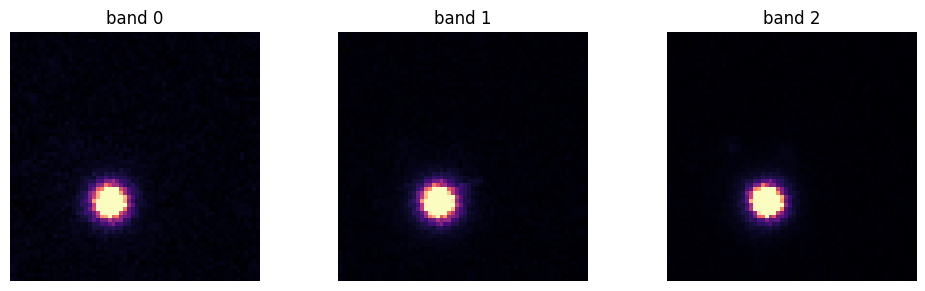

In [9]:
def load_npy(path):
    x = np.load(path)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    if x.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {x.shape} for {path}")

    if x.shape[0] == 3:
        pass
    elif x.shape[-1] == 3:
        x = np.transpose(x, (2, 0, 1))
    else:
        raise ValueError(f"Expected channel dimension of 3, got shape {x.shape} for {path}")

    return x

def astrophysical_stretch(x):
    x = np.maximum(x, 0.0)
    out = np.zeros_like(x, dtype=np.float32)

    for c in range(x.shape[0]):
        scale = np.percentile(x[c], 99.5)
        scale = max(scale, 1e-6)
        y = np.arcsinh(x[c] / scale)
        y = y / max(np.arcsinh(1.0), 1e-6)
        # robust post-normalization
        p1, p99 = np.percentile(y, 1.0), np.percentile(y, 99.0)
        if p99 > p1:
            y = (y - p1) / (p99 - p1)
        y = np.clip(y, 0.0, 1.0)
        out[c] = y.astype(np.float32)

    return out

def random_rot90(x):
    k = np.random.randint(0, 4)
    return np.rot90(x, k, axes=(1, 2)).copy()

def random_flip(x):
    if np.random.rand() < CFG.P_FLIP:
        x = x[:, :, ::-1].copy()
    if np.random.rand() < CFG.P_FLIP:
        x = x[:, ::-1, :].copy()
    return x

def random_shift(x, max_shift=3):
    if max_shift <= 0:
        return x
    dx = np.random.randint(-max_shift, max_shift + 1)
    dy = np.random.randint(-max_shift, max_shift + 1)
    pad = max_shift
    xp = np.pad(x, ((0, 0), (pad, pad), (pad, pad)), mode="reflect")
    h, w = x.shape[1:]
    sx = pad + dx
    sy = pad + dy
    return xp[:, sy:sy+h, sx:sx+w].copy()

def random_gain_jitter(x):
    if np.random.rand() < CFG.P_GAIN_JITTER:
        gains = np.random.uniform(
            1.0 - CFG.GAIN_JITTER,
            1.0 + CFG.GAIN_JITTER,
            size=(x.shape[0], 1, 1)
        ).astype(np.float32)
        x = x * gains
    return x

def random_band_dropout(x):
    if np.random.rand() < CFG.P_BAND_DROPOUT:
        c = np.random.randint(0, x.shape[0])
        x = x.copy()
        x[c] = 0.0
    return x

def random_noise(x):
    if np.random.rand() < CFG.P_NOISE:
        sigma = np.random.uniform(0.0, CFG.NOISE_STD_MAX)
        x = x + np.random.normal(0.0, sigma, size=x.shape).astype(np.float32)
    return np.clip(x, 0.0, 1.0)

class LensDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_npy(row.path)

        if self.augment:
            x = random_rot90(x)
            x = random_flip(x)
            x = random_shift(x, CFG.MAX_SHIFT)

        x = astrophysical_stretch(x)

        if self.augment:
            x = random_gain_jitter(x)
            x = random_band_dropout(x)
            x = random_noise(x)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(row.label, dtype=torch.float32)
        return x, y

sample_x, sample_y = LensDataset(trn_df, augment=True)[0]
print(sample_x.shape, sample_x.dtype, sample_y)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i in range(3):
    axes[i].imshow(sample_x[i].numpy(), cmap="magma")
    axes[i].set_title(f"band {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


In [10]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scipy.ndimage import sobel, gaussian_filter, laplace

# choose which dataframe to inspect
# if your dataframe names differ, change this line only
inspect_df = trn_df.copy()

def set_vis_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def normalize01(x):
    x = np.asarray(x, dtype=np.float32)
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    if hi <= lo:
        lo, hi = x.min(), x.max()
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    y = (x - lo) / (hi - lo)
    return np.clip(y, 0, 1).astype(np.float32)

def robust_linear_stretch(x):
    out = np.zeros_like(x, dtype=np.float32)
    for c in range(x.shape[0]):
        out[c] = normalize01(np.maximum(x[c], 0.0))
    return out

def log_stretch(x):
    x = np.maximum(x, 0.0)
    out = np.zeros_like(x, dtype=np.float32)
    for c in range(x.shape[0]):
        scale = np.percentile(x[c], 99.5)
        scale = max(scale, 1e-6)
        y = np.log1p(x[c] / scale)
        y = y / max(np.log1p(1.0), 1e-6)
        out[c] = normalize01(y)
    return out

def asinh_stretch(x):
    return astrophysical_stretch(x)

def to_pseudo_rgb(x, order=(0, 1, 2)):
    """
    x: [3, H, W]
    Returns pseudo-RGB image for display only.
    These are astronomical filters, not true camera RGB.
    """
    x = np.asarray(x, dtype=np.float32)
    rgb = np.stack([x[order[0]], x[order[1]], x[order[2]]], axis=-1)
    return np.clip(rgb, 0, 1)

def plot_bands(x, title="", cmap="magma", figsize=(12, 3)):
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for i in range(3):
        axes[i].imshow(x[i], cmap=cmap)
        axes[i].set_title(f"{title} band {i}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

def plot_rgb(x, title="", order=(0, 1, 2), figsize=(4, 4)):
    plt.figure(figsize=figsize)
    plt.imshow(to_pseudo_rgb(x, order=order))
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def edge_views(x_stretched):
    """
    x_stretched: [3, H, W] assumed in [0,1]
    Uses channel-mean image for edge diagnostics.
    """
    gray = x_stretched.mean(axis=0)

    blur = gaussian_filter(gray, sigma=1.0)
    sx = sobel(gray, axis=1)
    sy = sobel(gray, axis=0)
    sob = np.hypot(sx, sy)
    sob = normalize01(sob)
    lap = normalize01(np.abs(laplace(gray)))

    views = {
        "mean(gray)": normalize01(gray),
        "gaussian_blur": normalize01(blur),
        "sobel_magnitude": sob,
        "abs_laplacian": lap,
    }
    return views

def show_edge_views(x_stretched, title_prefix=""):
    views = edge_views(x_stretched)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, (name, img) in zip(axes, views.items()):
        ax.imshow(img, cmap="magma")
        ax.set_title(f"{title_prefix}{name}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def get_row(df, idx=None, label=None, seed=42):
    set_vis_seed(seed)
    tmp = df.copy()
    if label is not None:
        tmp = tmp[tmp["label"] == label].reset_index(drop=True)
    if idx is None:
        idx = np.random.randint(0, len(tmp))
    return tmp.iloc[idx]

def apply_geom_aug_only(x):
    x = random_rot90(x)
    x = random_flip(x)
    x = random_shift(x, CFG.MAX_SHIFT)
    return x

def apply_full_train_aug(x):
    # mirrors your dataset pipeline
    x = apply_geom_aug_only(x)
    x = astrophysical_stretch(x)
    x = random_gain_jitter(x)
    x = random_band_dropout(x)
    x = random_noise(x)
    return np.clip(x, 0, 1)

def summarize_array(x, name="array"):
    print(
        f"{name}: shape={x.shape} dtype={x.dtype} "
        f"min={x.min():.6f} max={x.max():.6f} "
        f"mean={x.mean():.6f} std={x.std():.6f}"
    )
    for c in range(x.shape[0]):
        print(
            f"  band {c}: min={x[c].min():.6f} max={x[c].max():.6f} "
            f"mean={x[c].mean():.6f} std={x[c].std():.6f}"
        )

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_lenses/939.npy
label: 1 -> lens
raw: shape=(3, 64, 64) dtype=float32 min=0.000000 max=1.000000 mean=0.035724 std=0.065398
  band 0: min=0.000000 max=1.000000 mean=0.045909 std=0.066812
  band 1: min=0.000000 max=1.000000 mean=0.034393 std=0.067976
  band 2: min=0.000000 max=1.000000 mean=0.026871 std=0.059684
asinh: shape=(3, 64, 64) dtype=float32 min=0.000000 max=1.000000 mean=0.086437 std=0.132540
  band 0: min=0.000000 max=1.000000 mean=0.098863 std=0.127784
  band 1: min=0.000000 max=1.000000 mean=0.078488 std=0.128042
  band 2: min=0.000000 max=1.000000 mean=0.081960 std=0.140497


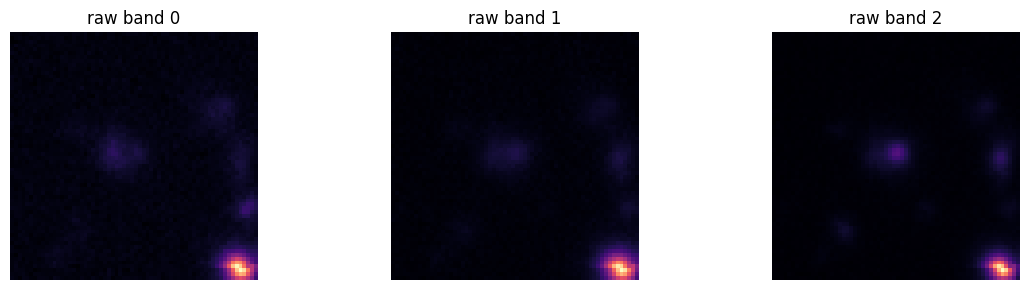

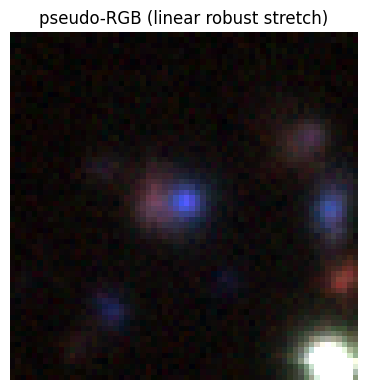

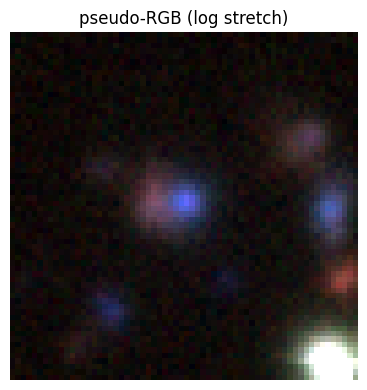

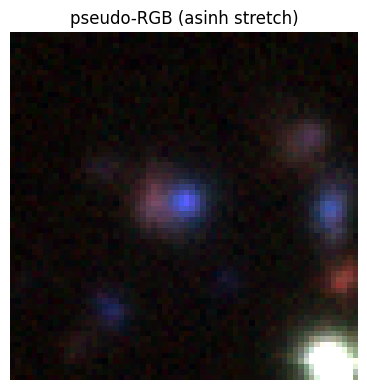

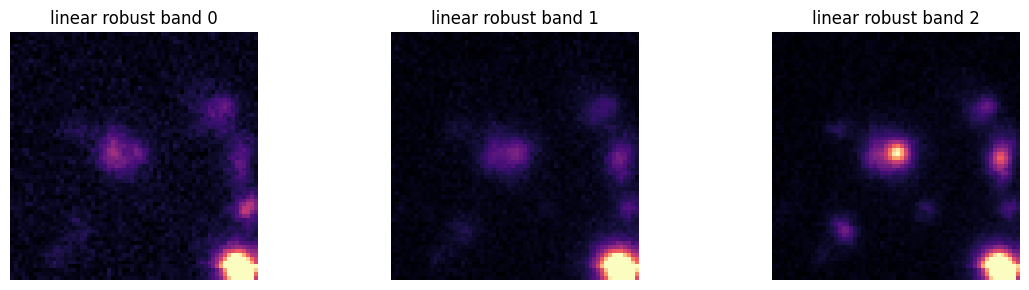

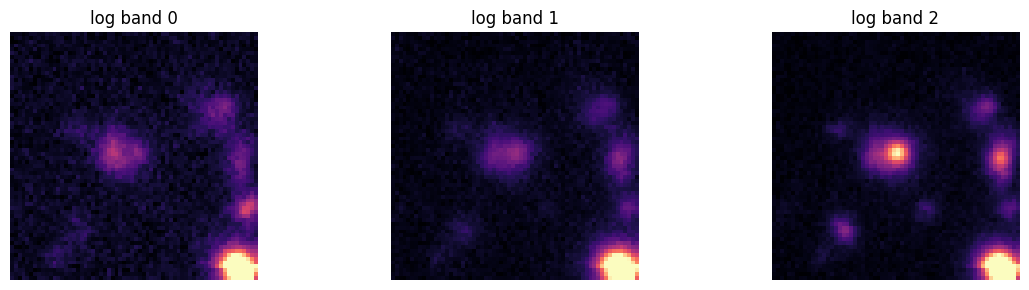

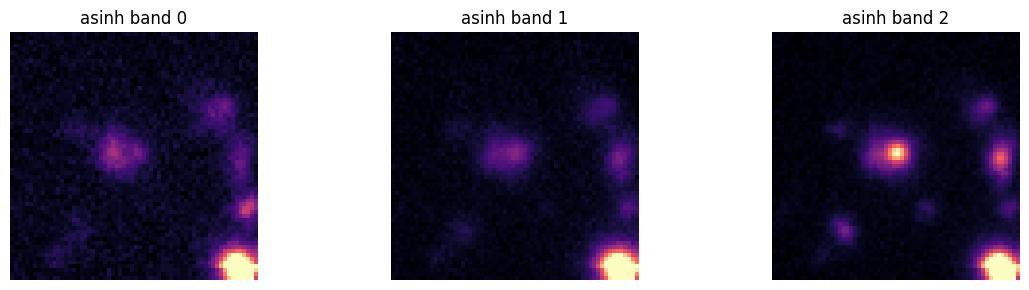

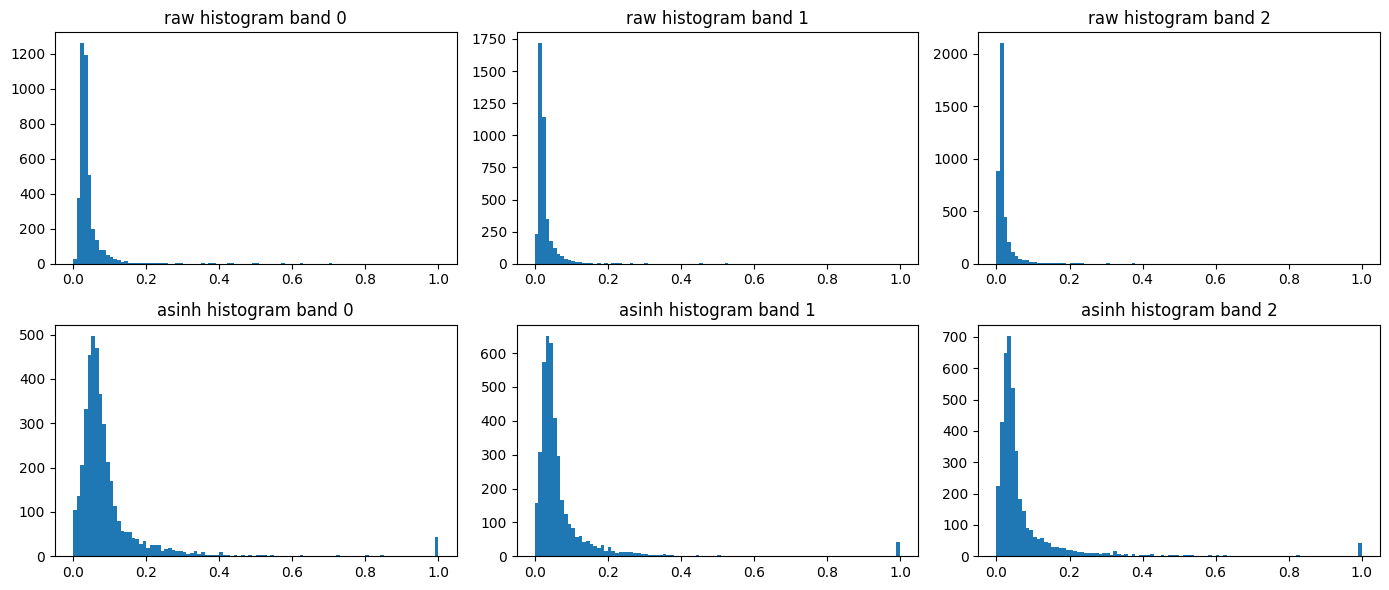

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_nonlenses/10848.npy
label: 0 -> non-lens
raw: shape=(3, 64, 64) dtype=float32 min=0.000000 max=1.000000 mean=0.229253 std=0.154897
  band 0: min=0.000000 max=1.000000 mean=0.393488 std=0.120598
  band 1: min=0.000000 max=1.000000 mean=0.211698 std=0.075026
  band 2: min=0.000000 max=1.000000 mean=0.082572 std=0.054865
asinh: shape=(3, 64, 64) dtype=float32 min=0.000000 max=1.000000 mean=0.371139 std=0.205462
  band 0: min=0.000000 max=1.000000 mean=0.483285 std=0.198685
  band 1: min=0.000000 max=1.000000 mean=0.404988 std=0.181786
  band 2: min=0.000000 max=1.000000 mean=0.225143 std=0.138146


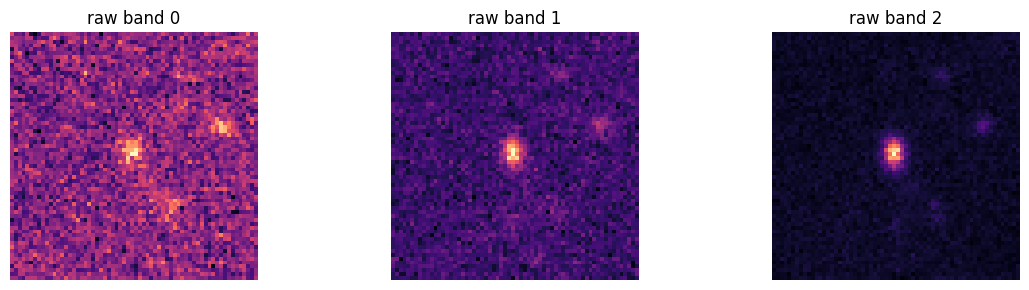

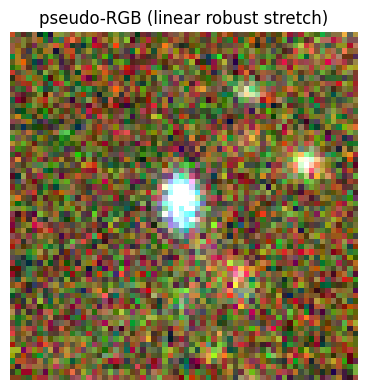

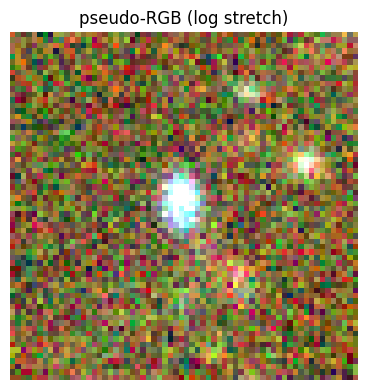

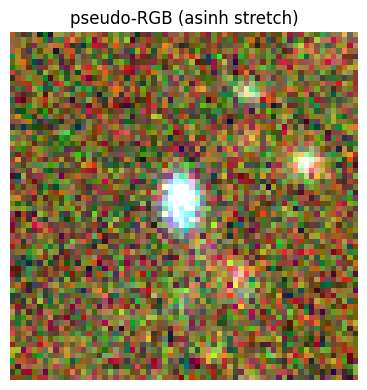

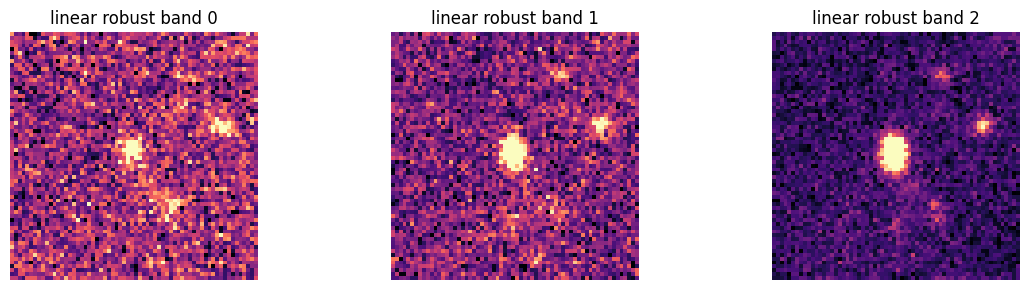

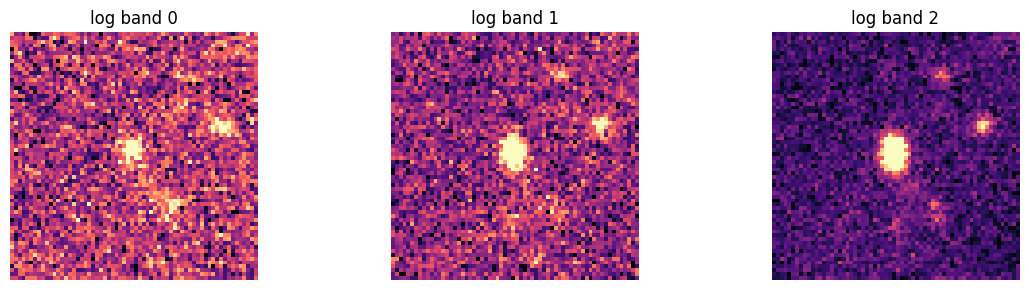

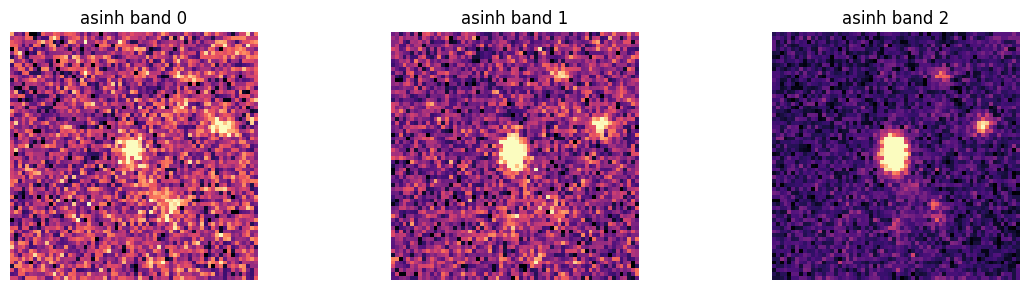

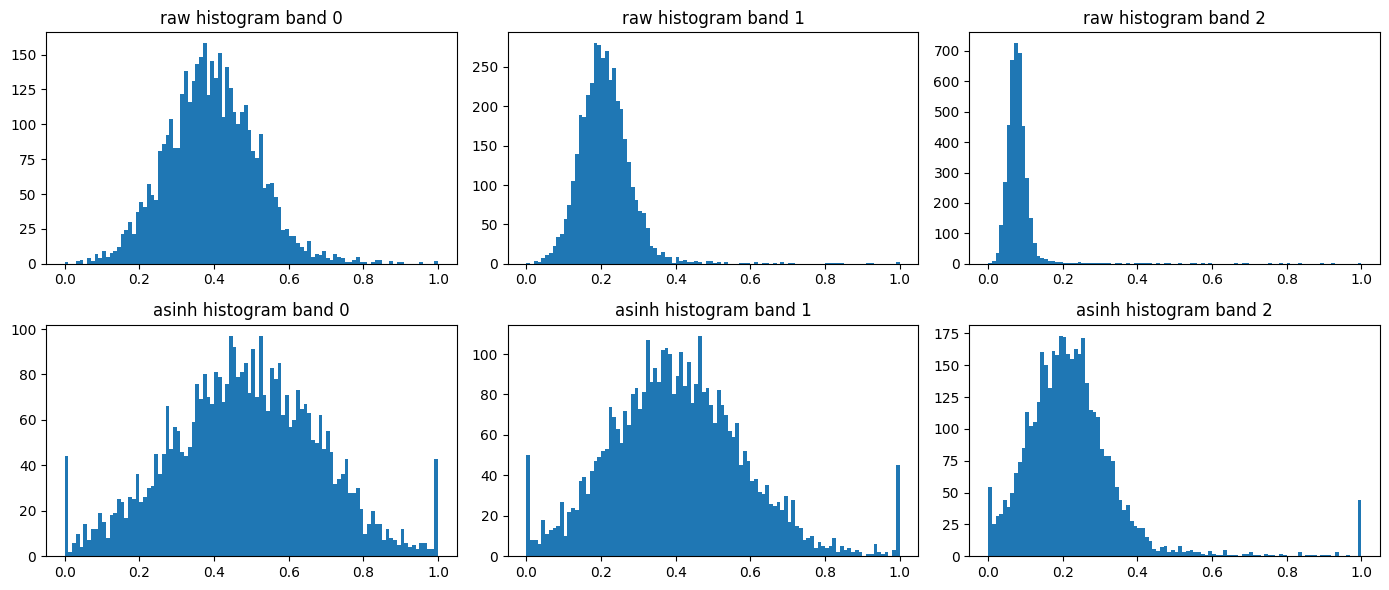

In [11]:
def inspect_sample(df, idx=None, label=None, seed=42, rgb_order=(0, 1, 2)):
    row = get_row(df, idx=idx, label=label, seed=seed)
    x_raw = load_npy(row.path)

    x_lin = robust_linear_stretch(x_raw)
    x_log = log_stretch(x_raw)
    x_asinh = asinh_stretch(x_raw)

    print("path:", row.path)
    print("label:", int(row.label), "->", "lens" if int(row.label) == 1 else "non-lens")
    summarize_array(x_raw, "raw")
    summarize_array(x_asinh, "asinh")

    plot_bands(x_raw, title="raw", cmap="magma")
    plot_rgb(x_lin, title="pseudo-RGB (linear robust stretch)", order=rgb_order)
    plot_rgb(x_log, title="pseudo-RGB (log stretch)", order=rgb_order)
    plot_rgb(x_asinh, title="pseudo-RGB (asinh stretch)", order=rgb_order)

    plot_bands(x_lin, title="linear robust", cmap="magma")
    plot_bands(x_log, title="log", cmap="magma")
    plot_bands(x_asinh, title="asinh", cmap="magma")

    # band-wise histograms before and after stretch
    fig, axes = plt.subplots(2, 3, figsize=(14, 6))
    for c in range(3):
        axes[0, c].hist(x_raw[c].ravel(), bins=100)
        axes[0, c].set_title(f"raw histogram band {c}")
        axes[1, c].hist(x_asinh[c].ravel(), bins=100)
        axes[1, c].set_title(f"asinh histogram band {c}")
    plt.tight_layout()
    plt.show()

# Examples:
inspect_sample(inspect_df, label=1, seed=1)   # random lens
inspect_sample(inspect_df, label=0, seed=2)   # random non-lens

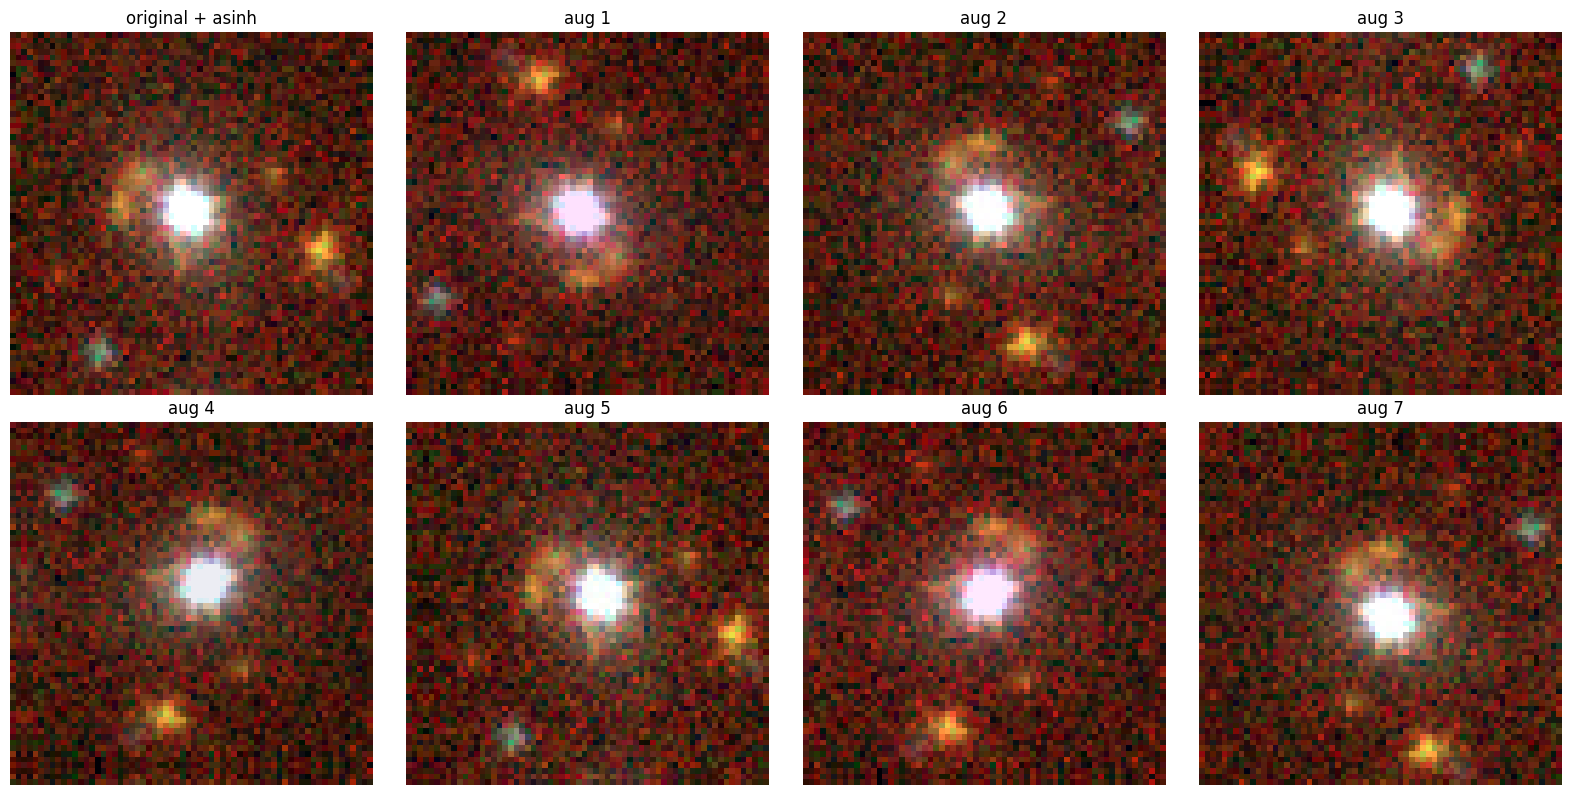

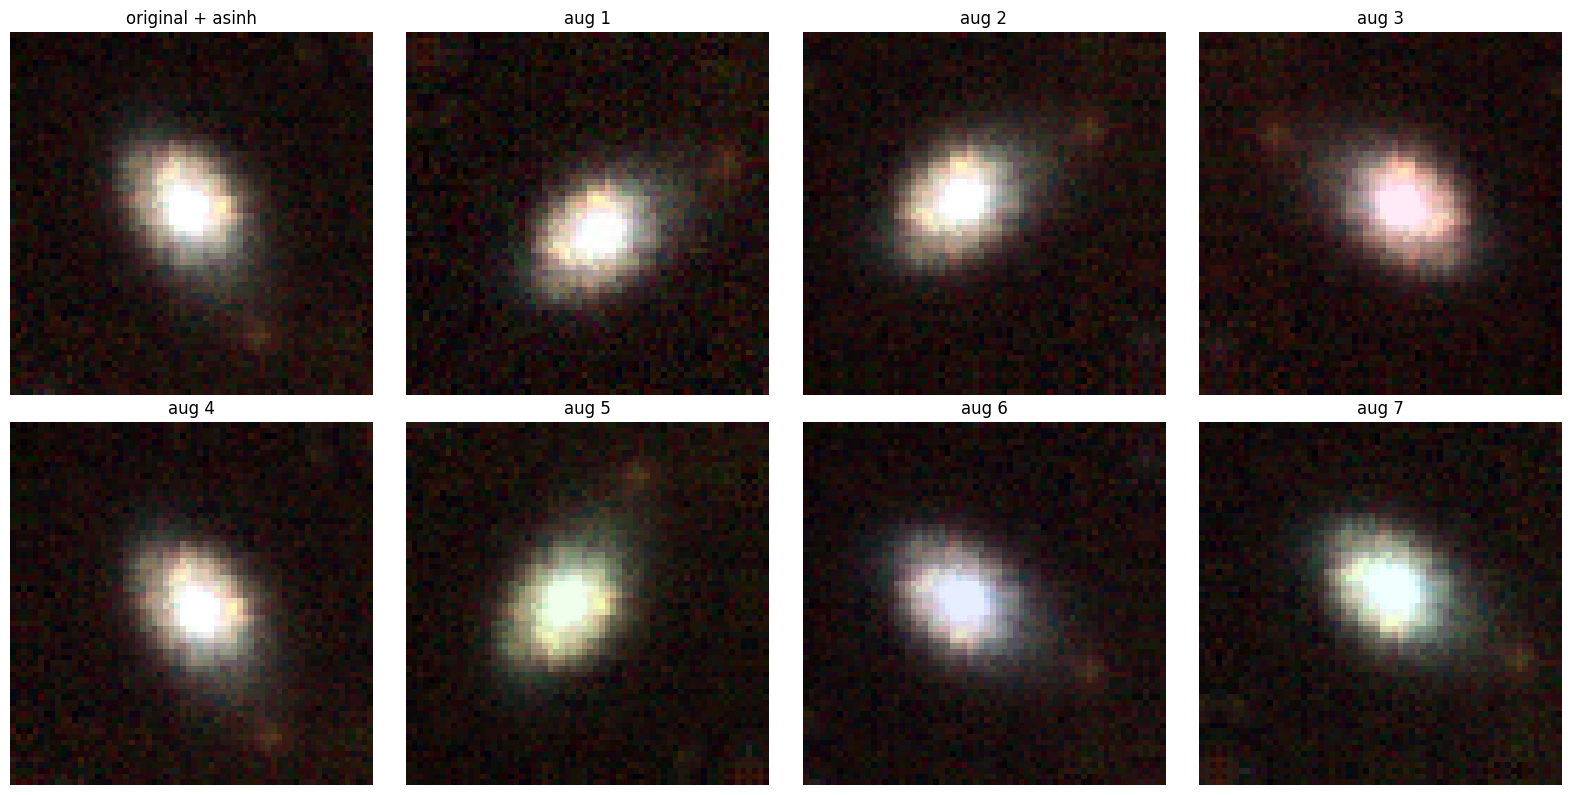

In [19]:
def show_augmentations(df, idx=None, label=None, seed=42, n=8, rgb_order=(0, 1, 2)):
    row = get_row(df, idx=idx, label=label, seed=seed)
    x_raw = load_npy(row.path)

    # original stretched
    x0 = asinh_stretch(x_raw)

    figs = [x0]
    titles = ["original + asinh"]

    for i in range(n - 1):
        set_vis_seed(seed + i + 1)
        xa = apply_full_train_aug(x_raw.copy())
        figs.append(xa)
        titles.append(f"aug {i+1}")

    rows = int(np.ceil(n / 4))
    cols = min(4, n)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, img, title in zip(axes, figs, titles):
        ax.imshow(to_pseudo_rgb(img, order=rgb_order))
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[len(figs):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Example:
show_augmentations(inspect_df, label=1, seed=10, n=8)  # random lens  
show_augmentations(inspect_df, label=0, seed=20, n=8)  # random non-lens

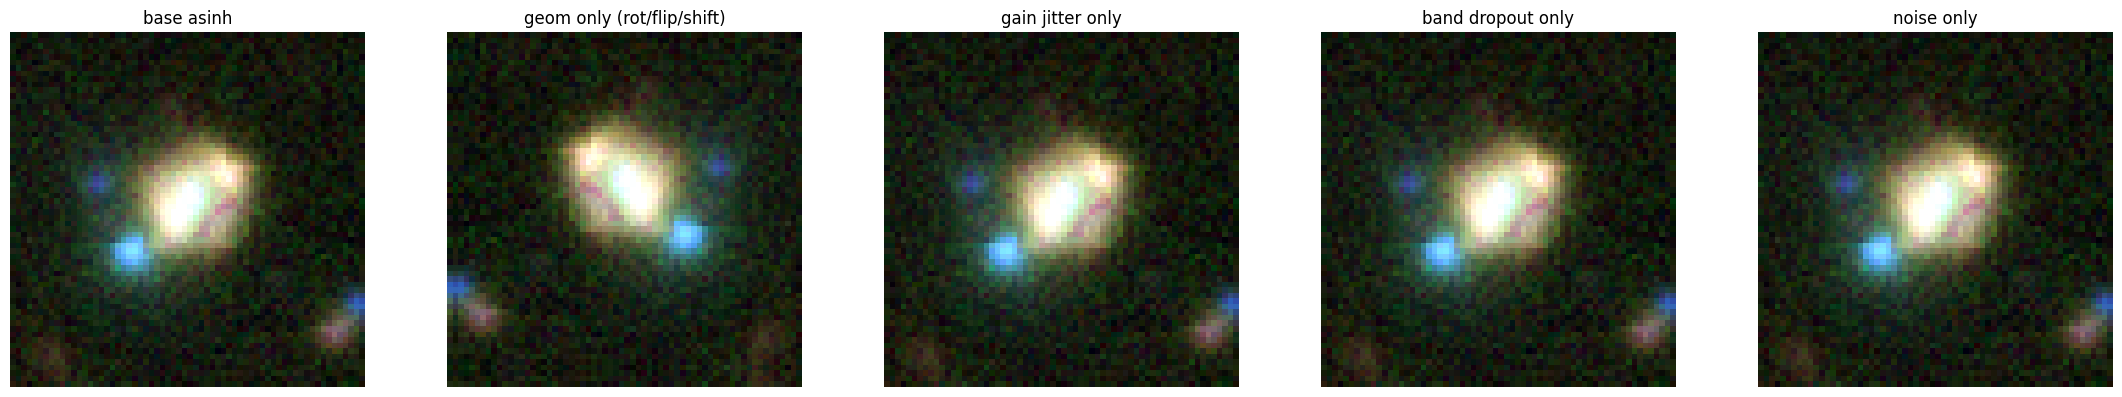

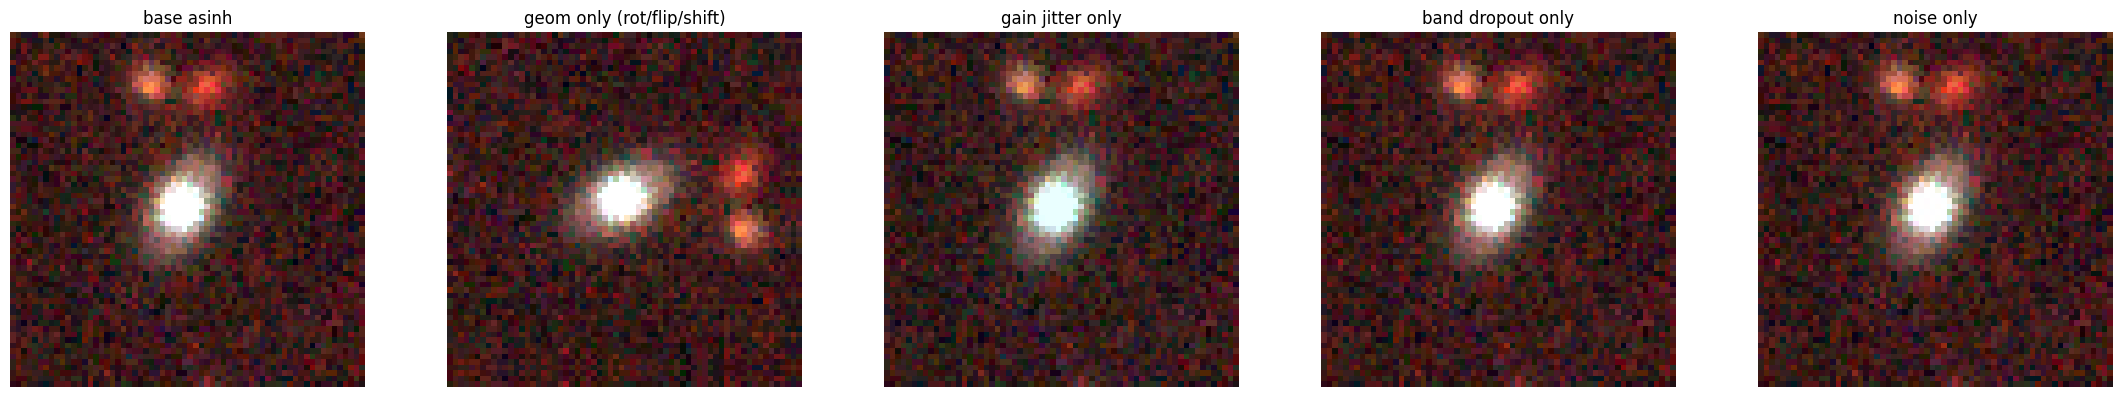

In [12]:
def show_each_aug_component(df, idx=None, label=None, seed=42, rgb_order=(0, 1, 2)):
    row = get_row(df, idx=idx, label=label, seed=seed)
    x_raw = load_npy(row.path)

    set_vis_seed(seed)
    x_base = asinh_stretch(x_raw.copy())

    set_vis_seed(seed)
    x_geom = apply_geom_aug_only(x_raw.copy())
    x_geom = asinh_stretch(x_geom)

    set_vis_seed(seed)
    x_gain = asinh_stretch(x_raw.copy())
    x_gain = random_gain_jitter(x_gain.copy())

    set_vis_seed(seed)
    x_drop = asinh_stretch(x_raw.copy())
    x_drop = random_band_dropout(x_drop.copy())

    set_vis_seed(seed)
    x_noise = asinh_stretch(x_raw.copy())
    x_noise = random_noise(x_noise.copy())

    imgs = [x_base, x_geom, x_gain, x_drop, x_noise]
    titles = [
        "base asinh",
        "geom only (rot/flip/shift)",
        "gain jitter only",
        "band dropout only",
        "noise only",
    ]

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(to_pseudo_rgb(img, order=rgb_order))
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Example:
show_each_aug_component(inspect_df, label=1, seed=123)
show_each_aug_component(inspect_df, label=0, seed=456)

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_lenses/320.npy
label: 1 -> lens


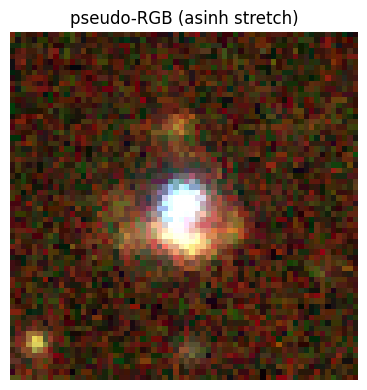

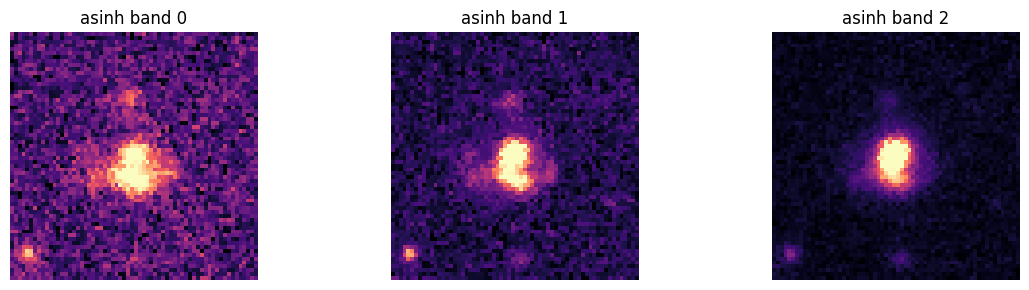

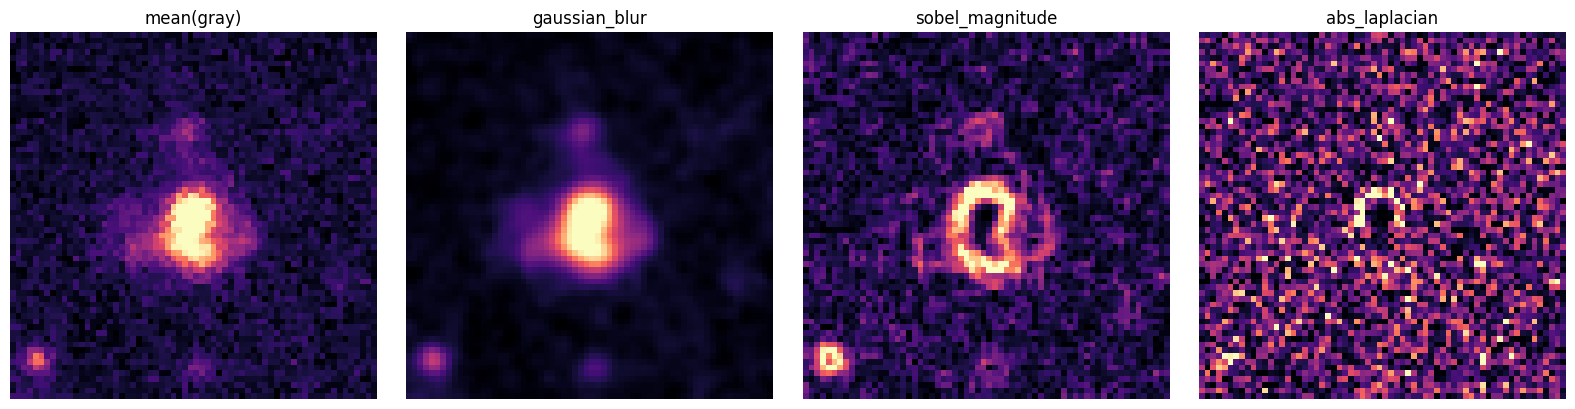

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_nonlenses/6890.npy
label: 0 -> non-lens


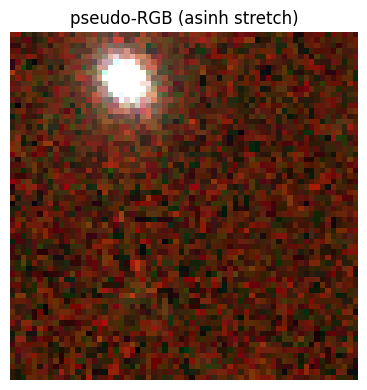

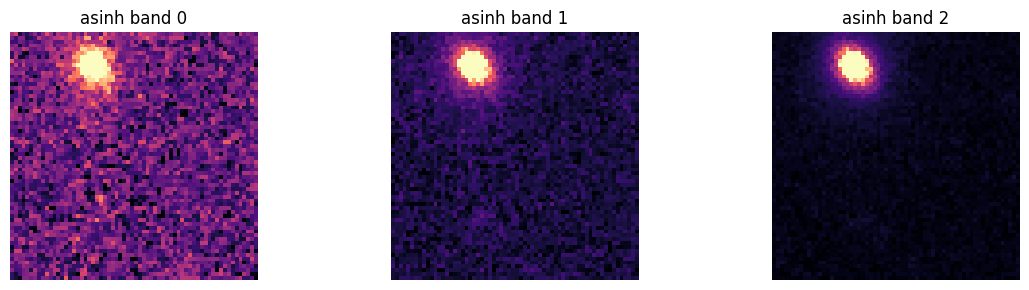

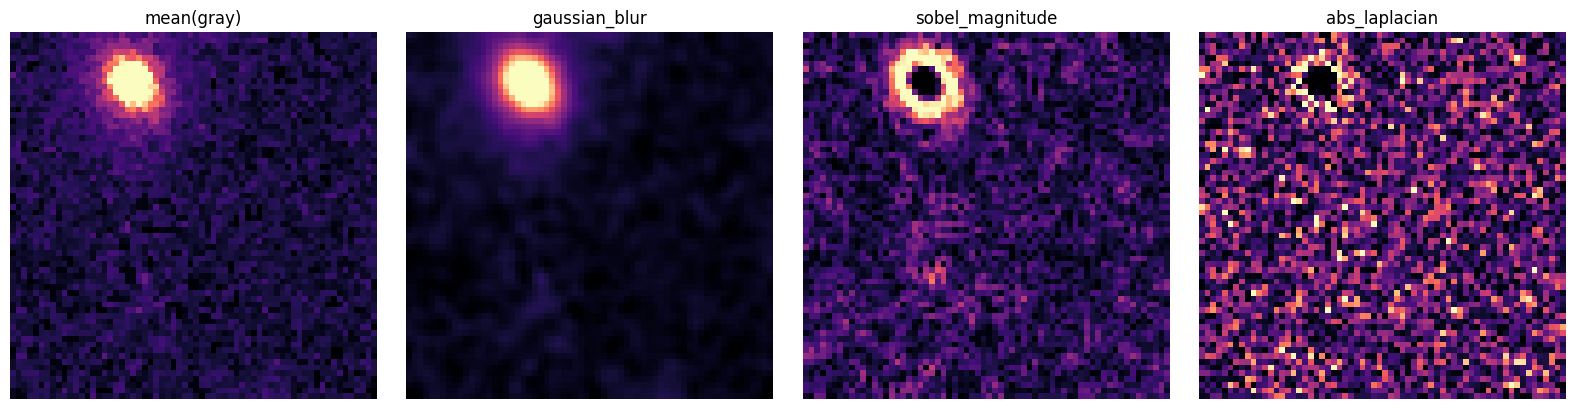

In [13]:
def inspect_filters(df, idx=None, label=None, seed=42):
    row = get_row(df, idx=idx, label=label, seed=seed)
    x_raw = load_npy(row.path)
    x_asinh = asinh_stretch(x_raw)

    print("path:", row.path)
    print("label:", int(row.label), "->", "lens" if int(row.label) == 1 else "non-lens")

    plot_rgb(x_asinh, title="pseudo-RGB (asinh stretch)")
    plot_bands(x_asinh, title="asinh", cmap="magma")
    show_edge_views(x_asinh, title_prefix="")

# Example:
inspect_filters(inspect_df, label=1, seed=7)
inspect_filters(inspect_df, label=0, seed=8)

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_lenses/925.npy
label: 1 -> lens


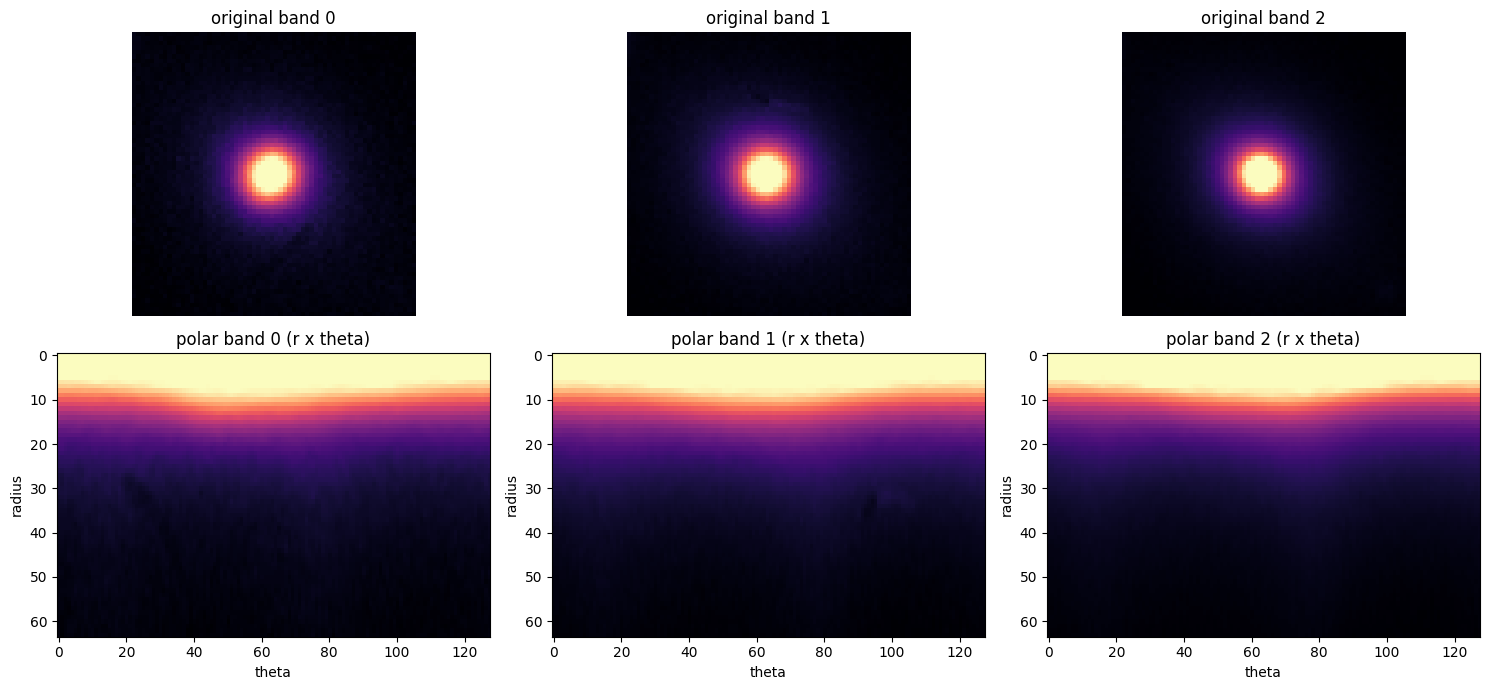

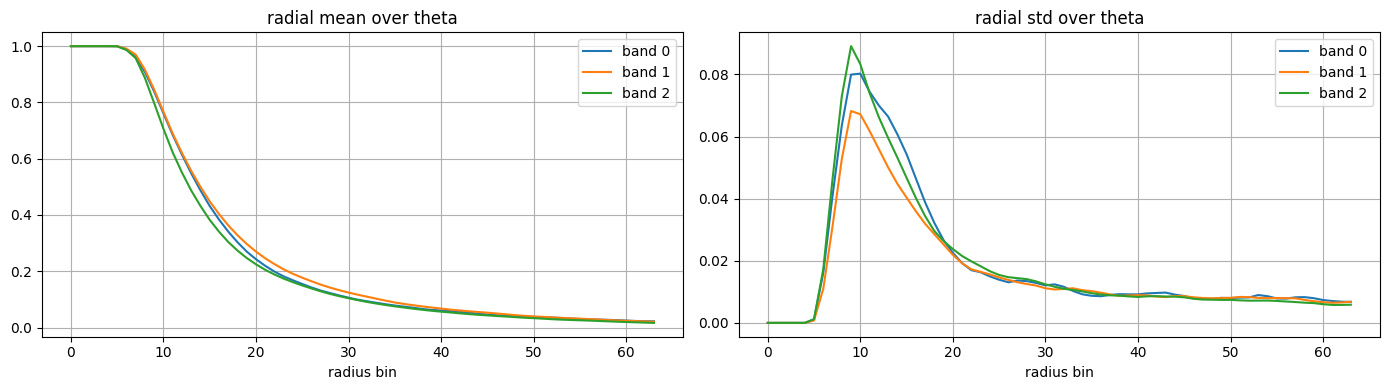

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_nonlenses/17329.npy
label: 0 -> non-lens


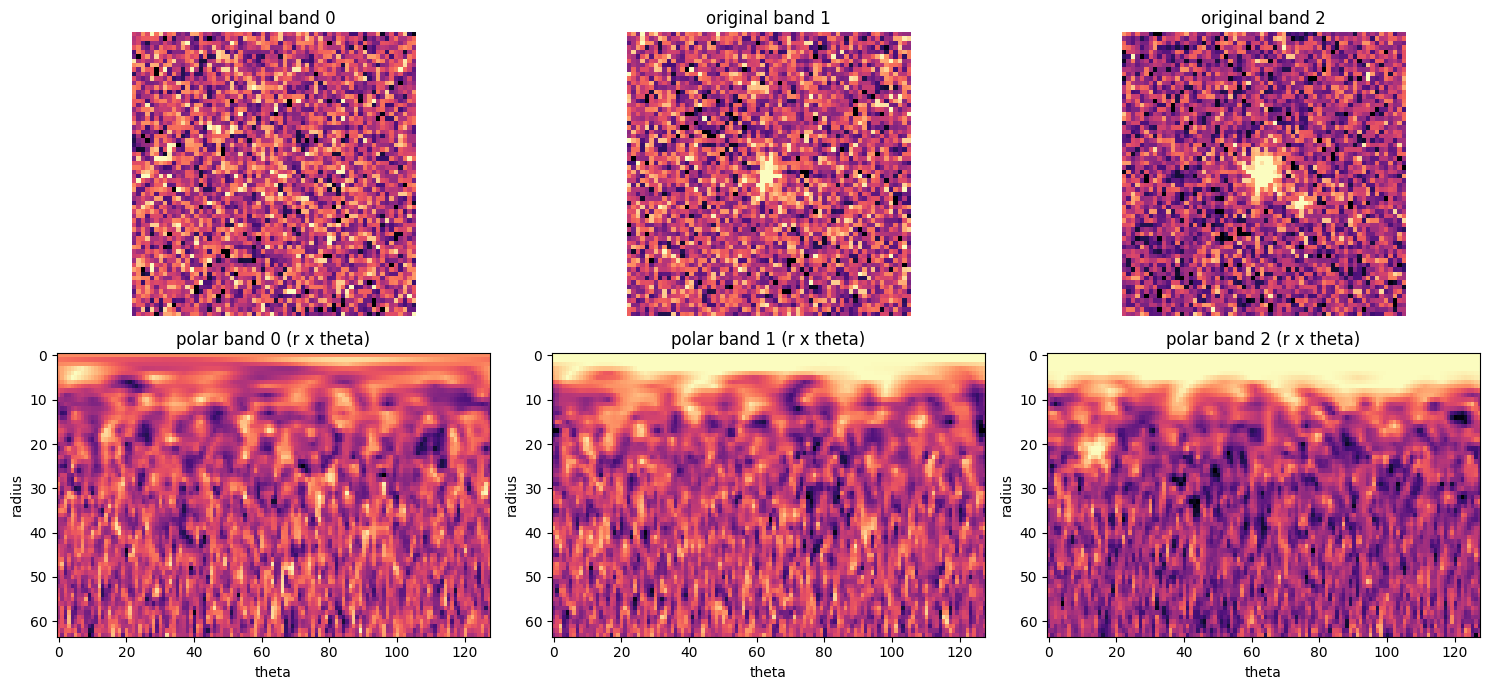

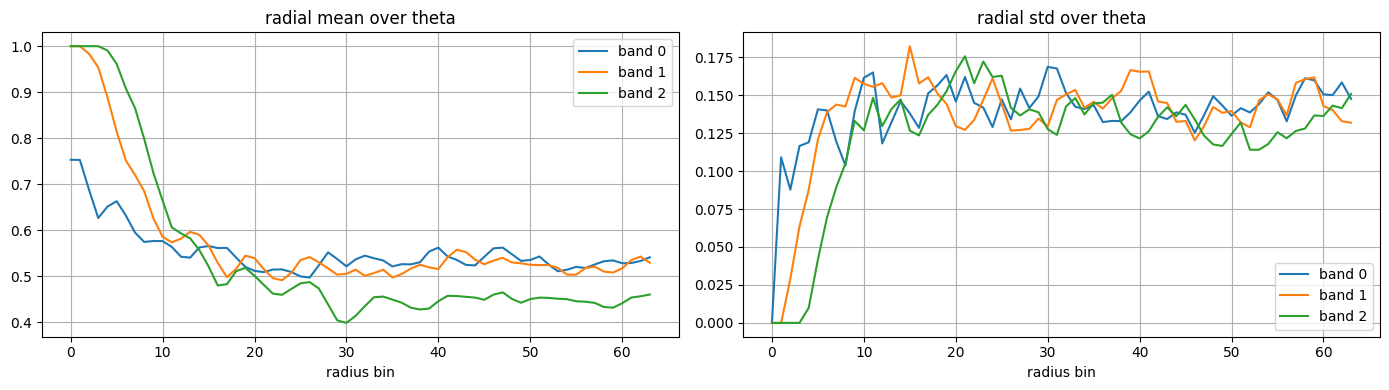

In [14]:
# Use your existing PolarTransform class if it is already defined.
# Otherwise define it here:

import math
import torch.nn.functional as F
import torch.nn as nn

class PolarTransformVis(nn.Module):
    def __init__(self, radial_bins=64, angular_bins=128):
        super().__init__()
        r = torch.linspace(0, 1, radial_bins)
        theta = torch.linspace(0, 2 * math.pi, angular_bins)
        rr, tt = torch.meshgrid(r, theta, indexing="ij")
        x = rr * torch.cos(tt)
        y = rr * torch.sin(tt)
        grid = torch.stack([x, y], dim=-1)
        self.register_buffer("base_grid", grid)

    def forward(self, x):
        b = x.shape[0]
        grid = self.base_grid.unsqueeze(0).repeat(b, 1, 1, 1)
        polar = F.grid_sample(
            x, grid,
            mode="bilinear",
            padding_mode="zeros",
            align_corners=True
        )
        return polar  # [B, C, R, T]

polar_vis = PolarTransformVis(radial_bins=64, angular_bins=128)

def inspect_polar_and_radial(df, idx=None, label=None, seed=42, rgb_order=(0, 1, 2)):
    row = get_row(df, idx=idx, label=label, seed=seed)
    x_raw = load_npy(row.path)
    x = asinh_stretch(x_raw)

    xt = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # [1,3,H,W]
    with torch.no_grad():
        polar = polar_vis(xt).squeeze(0).cpu().numpy()      # [3,R,T]

    radial_mean = polar.mean(axis=-1)  # [3,R]
    radial_std  = polar.std(axis=-1)   # [3,R]

    print("path:", row.path)
    print("label:", int(row.label), "->", "lens" if int(row.label) == 1 else "non-lens")

    # original and polar side by side
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    for c in range(3):
        axes[0, c].imshow(x[c], cmap="magma")
        axes[0, c].set_title(f"original band {c}")
        axes[0, c].axis("off")

        axes[1, c].imshow(polar[c], cmap="magma", aspect="auto")
        axes[1, c].set_title(f"polar band {c} (r x theta)")
        axes[1, c].set_xlabel("theta")
        axes[1, c].set_ylabel("radius")
    plt.tight_layout()
    plt.show()

    # radial mean/std
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for c in range(3):
        axes[0].plot(radial_mean[c], label=f"band {c}")
        axes[1].plot(radial_std[c], label=f"band {c}")
    axes[0].set_title("radial mean over theta")
    axes[1].set_title("radial std over theta")
    axes[0].set_xlabel("radius bin")
    axes[1].set_xlabel("radius bin")
    axes[0].legend()
    axes[1].legend()
    axes[0].grid(True)
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

# Example:
inspect_polar_and_radial(inspect_df, label=1, seed=11)
inspect_polar_and_radial(inspect_df, label=0, seed=12)

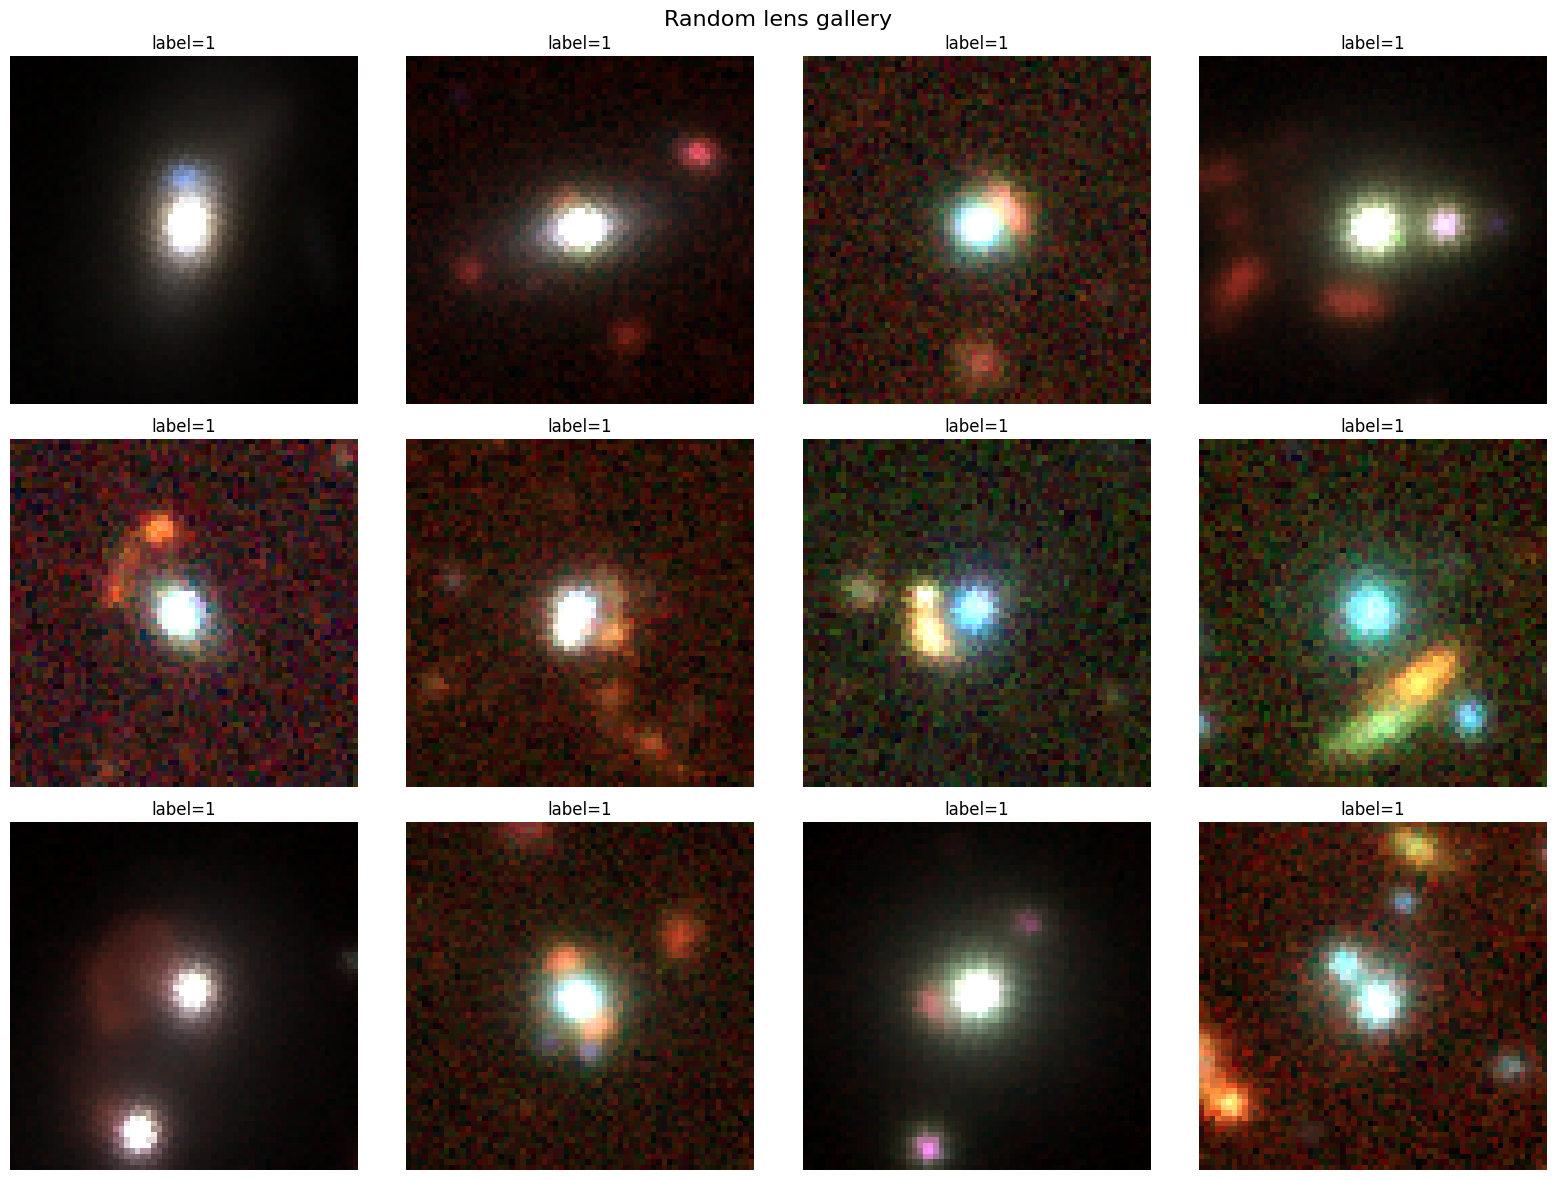

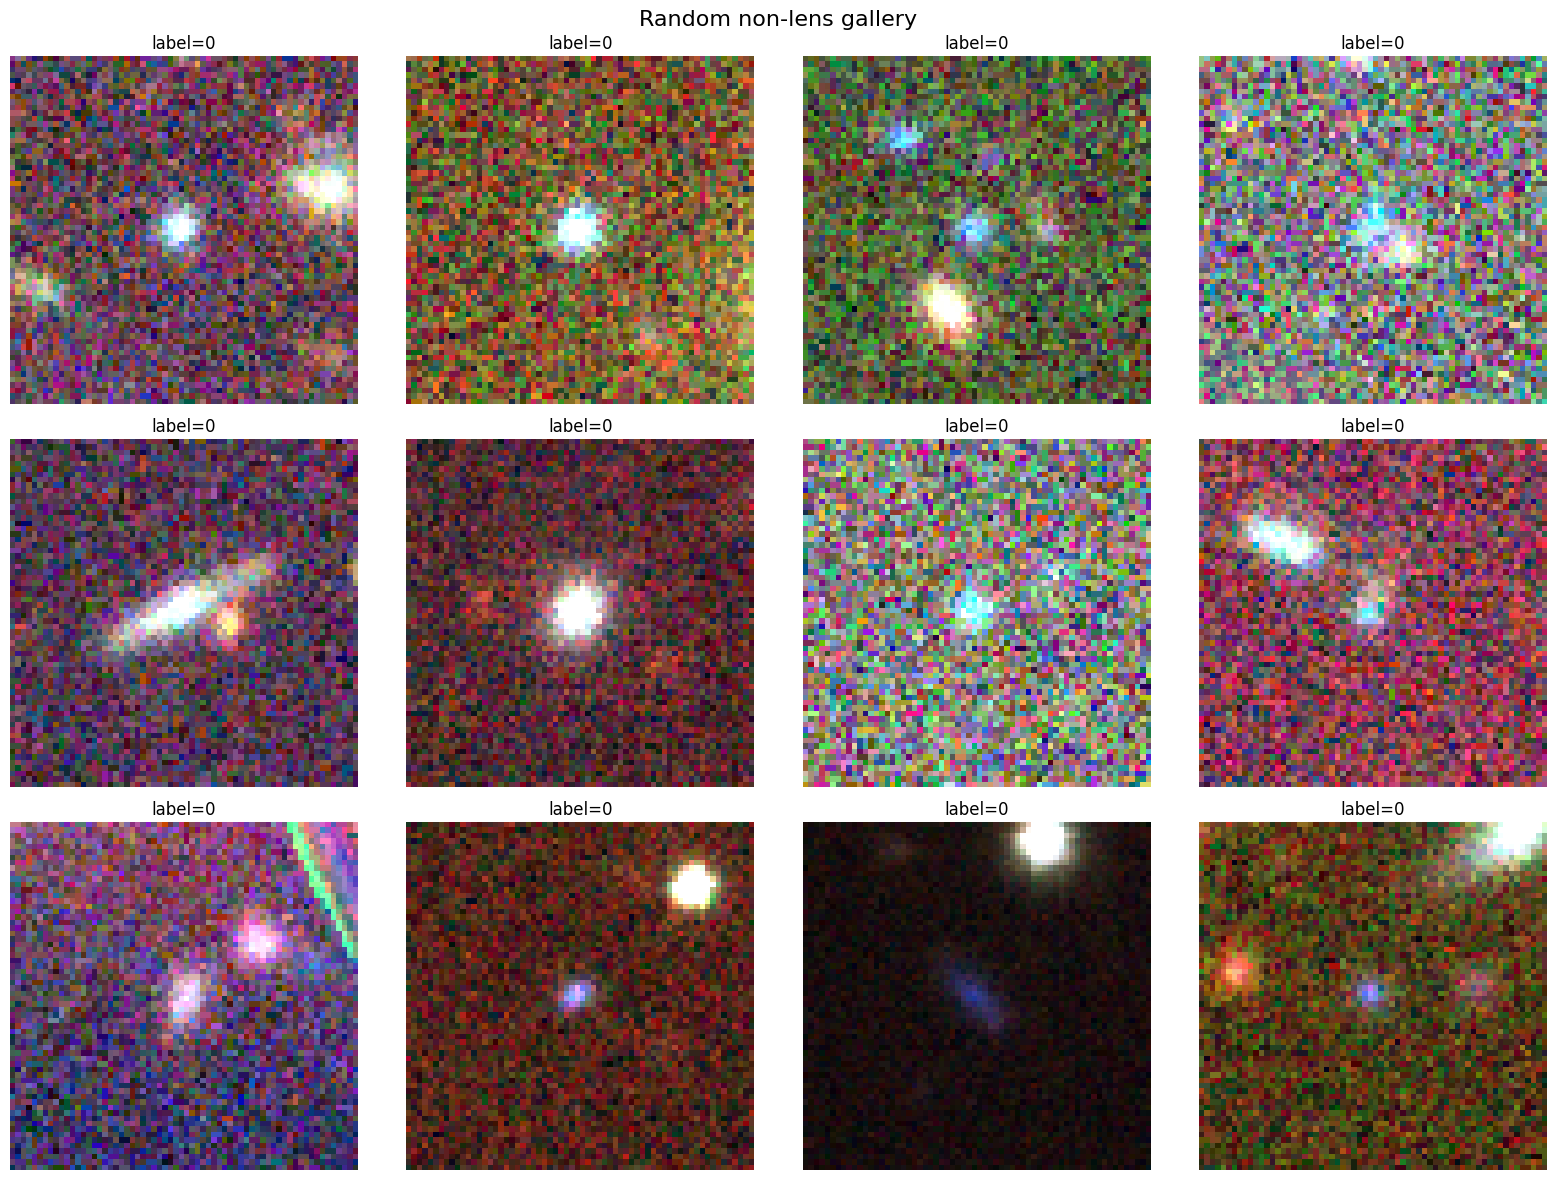

In [15]:
def show_class_gallery(df, label, n=12, seed=42, rgb_order=(0, 1, 2), title=None):
    set_vis_seed(seed)
    sub = df[df["label"] == label].sample(n=min(n, (df["label"] == label).sum()), random_state=seed).reset_index(drop=True)

    cols = 4
    rows = int(np.ceil(len(sub) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sub.iterrows()):
        x = asinh_stretch(load_npy(row.path))
        ax.imshow(to_pseudo_rgb(x, order=rgb_order))
        ax.set_title(f"label={int(row.label)}")
        ax.axis("off")

    for ax in axes[len(sub):]:
        ax.axis("off")

    if title is None:
        title = "lenses" if label == 1 else "non-lenses"
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

show_class_gallery(inspect_df, label=1, n=12, seed=101, title="Random lens gallery")
show_class_gallery(inspect_df, label=0, n=12, seed=202, title="Random non-lens gallery")

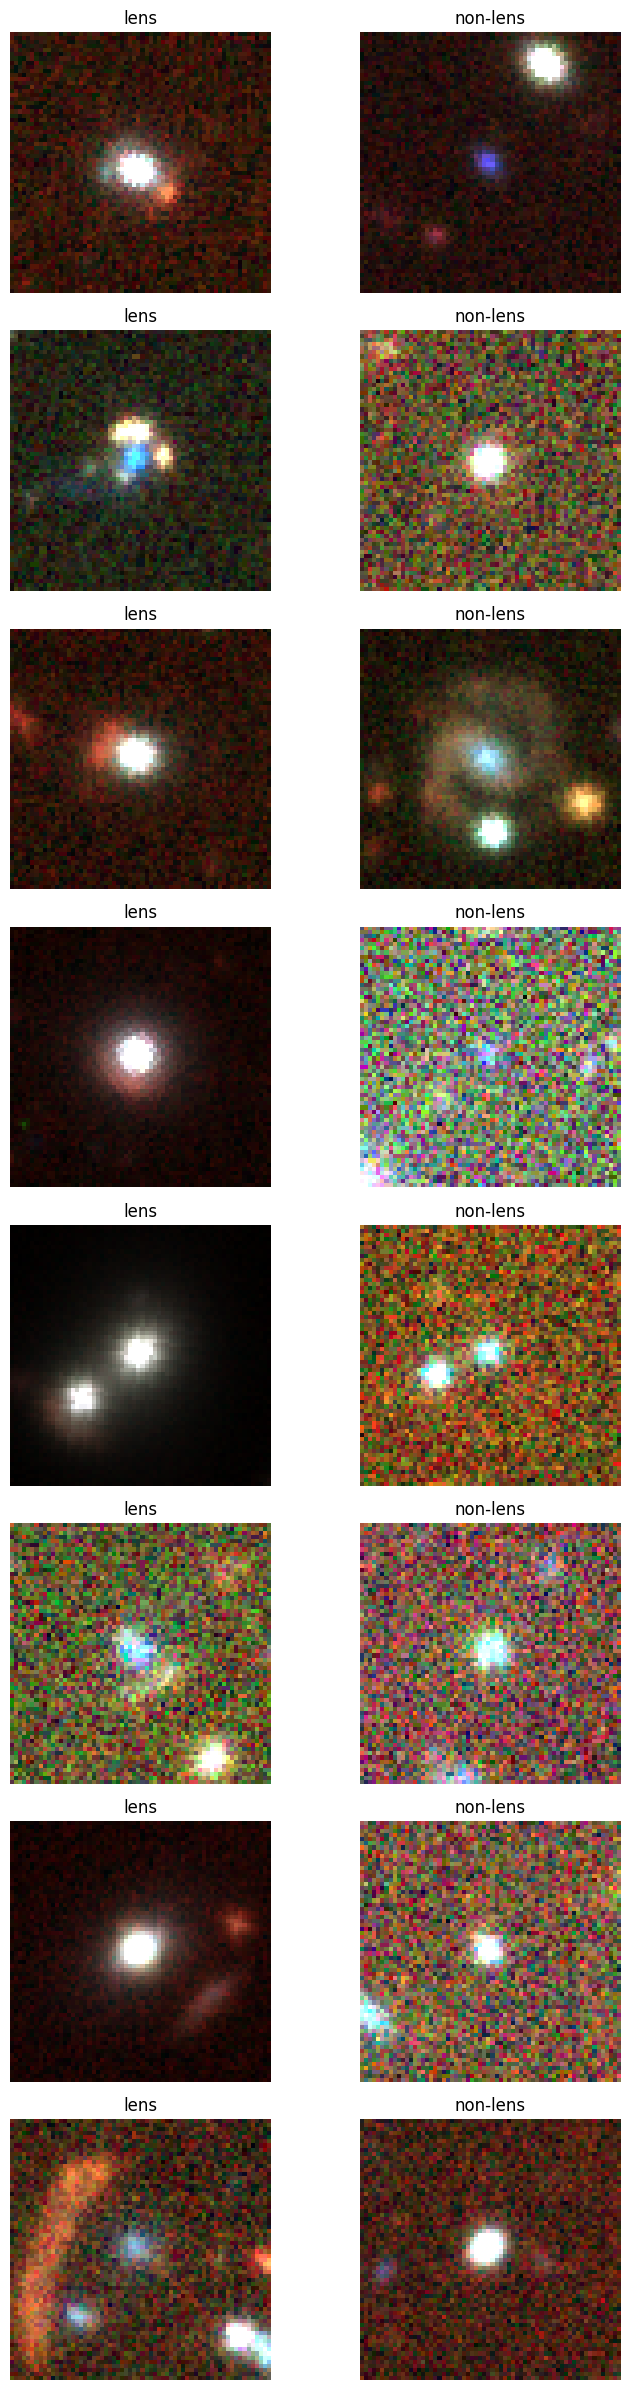

In [16]:
def show_lens_vs_nonlens_pairs(df, n=8, seed=42, rgb_order=(0, 1, 2)):
    set_vis_seed(seed)
    pos = df[df["label"] == 1].sample(n=min(n, (df["label"] == 1).sum()), random_state=seed).reset_index(drop=True)
    neg = df[df["label"] == 0].sample(n=min(n, (df["label"] == 0).sum()), random_state=seed + 1).reset_index(drop=True)

    fig, axes = plt.subplots(n, 2, figsize=(8, 3 * n))
    if n == 1:
        axes = np.array([axes])

    for i in range(n):
        x_pos = asinh_stretch(load_npy(pos.iloc[i].path))
        x_neg = asinh_stretch(load_npy(neg.iloc[i].path))

        axes[i, 0].imshow(to_pseudo_rgb(x_pos, order=rgb_order))
        axes[i, 0].set_title("lens")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(to_pseudo_rgb(x_neg, order=rgb_order))
        axes[i, 1].set_title("non-lens")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

show_lens_vs_nonlens_pairs(inspect_df, n=8, seed=303)

,total_flux,mean_flux,max_pixel,std_pixel,peak_radius,label
0,2082.057617,0.169438,1.0,0.182335,0,0
1,3950.388428,0.321483,1.0,0.209551,0,0
2,2872.498535,0.233765,1.0,0.189711,0,0
3,4842.247559,0.394063,1.0,0.196398,2,0
4,5789.277832,0.471133,1.0,0.207333,0,0


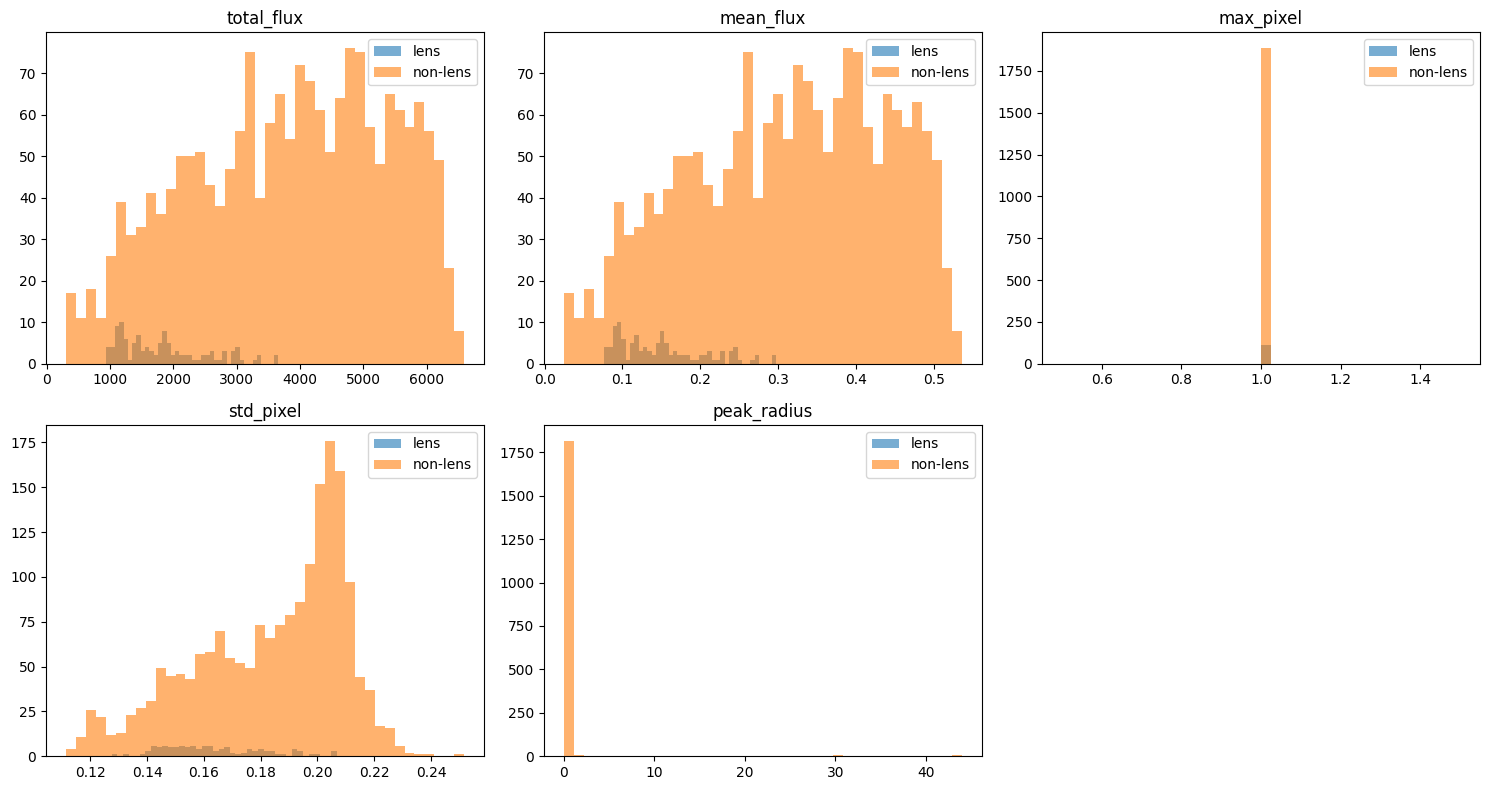

In [17]:
def radial_profile_mean_over_channels(x):
    """
    x: [3,H,W], preferably stretched
    returns radial mean profile of channel-mean image
    """
    img = x.mean(axis=0)
    h, w = img.shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    yy, xx = np.indices((h, w))
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

    r_int = rr.astype(np.int32)
    max_r = r_int.max()

    prof = np.zeros(max_r + 1, dtype=np.float32)
    cnt = np.zeros(max_r + 1, dtype=np.float32)

    for r in range(max_r + 1):
        mask = (r_int == r)
        if mask.any():
            prof[r] = img[mask].mean()
            cnt[r] = mask.sum()

    return prof

def quick_features_from_path(path):
    x_raw = load_npy(path)
    x = asinh_stretch(x_raw)

    prof = radial_profile_mean_over_channels(x)
    peak_r = int(np.argmax(prof))
    return {
        "total_flux": float(x.sum()),
        "mean_flux": float(x.mean()),
        "max_pixel": float(x.max()),
        "std_pixel": float(x.std()),
        "peak_radius": peak_r,
    }

def make_feature_df(df, max_rows=2000, seed=42):
    tmp = df.sample(n=min(max_rows, len(df)), random_state=seed).reset_index(drop=True)
    rows = []
    for _, row in tmp.iterrows():
        feat = quick_features_from_path(row.path)
        feat["label"] = int(row.label)
        rows.append(feat)
    return pd.DataFrame(rows)

feat_df = make_feature_df(inspect_df, max_rows=2000, seed=42)
display(feat_df.head())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ["total_flux", "mean_flux", "max_pixel", "std_pixel", "peak_radius"]
axes = axes.reshape(-1)

for ax, col in zip(axes, cols):
    ax.hist(feat_df[feat_df.label == 1][col], bins=40, alpha=0.6, label="lens")
    ax.hist(feat_df[feat_df.label == 0][col], bins=40, alpha=0.6, label="non-lens")
    ax.set_title(col)
    ax.legend()

for ax in axes[len(cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

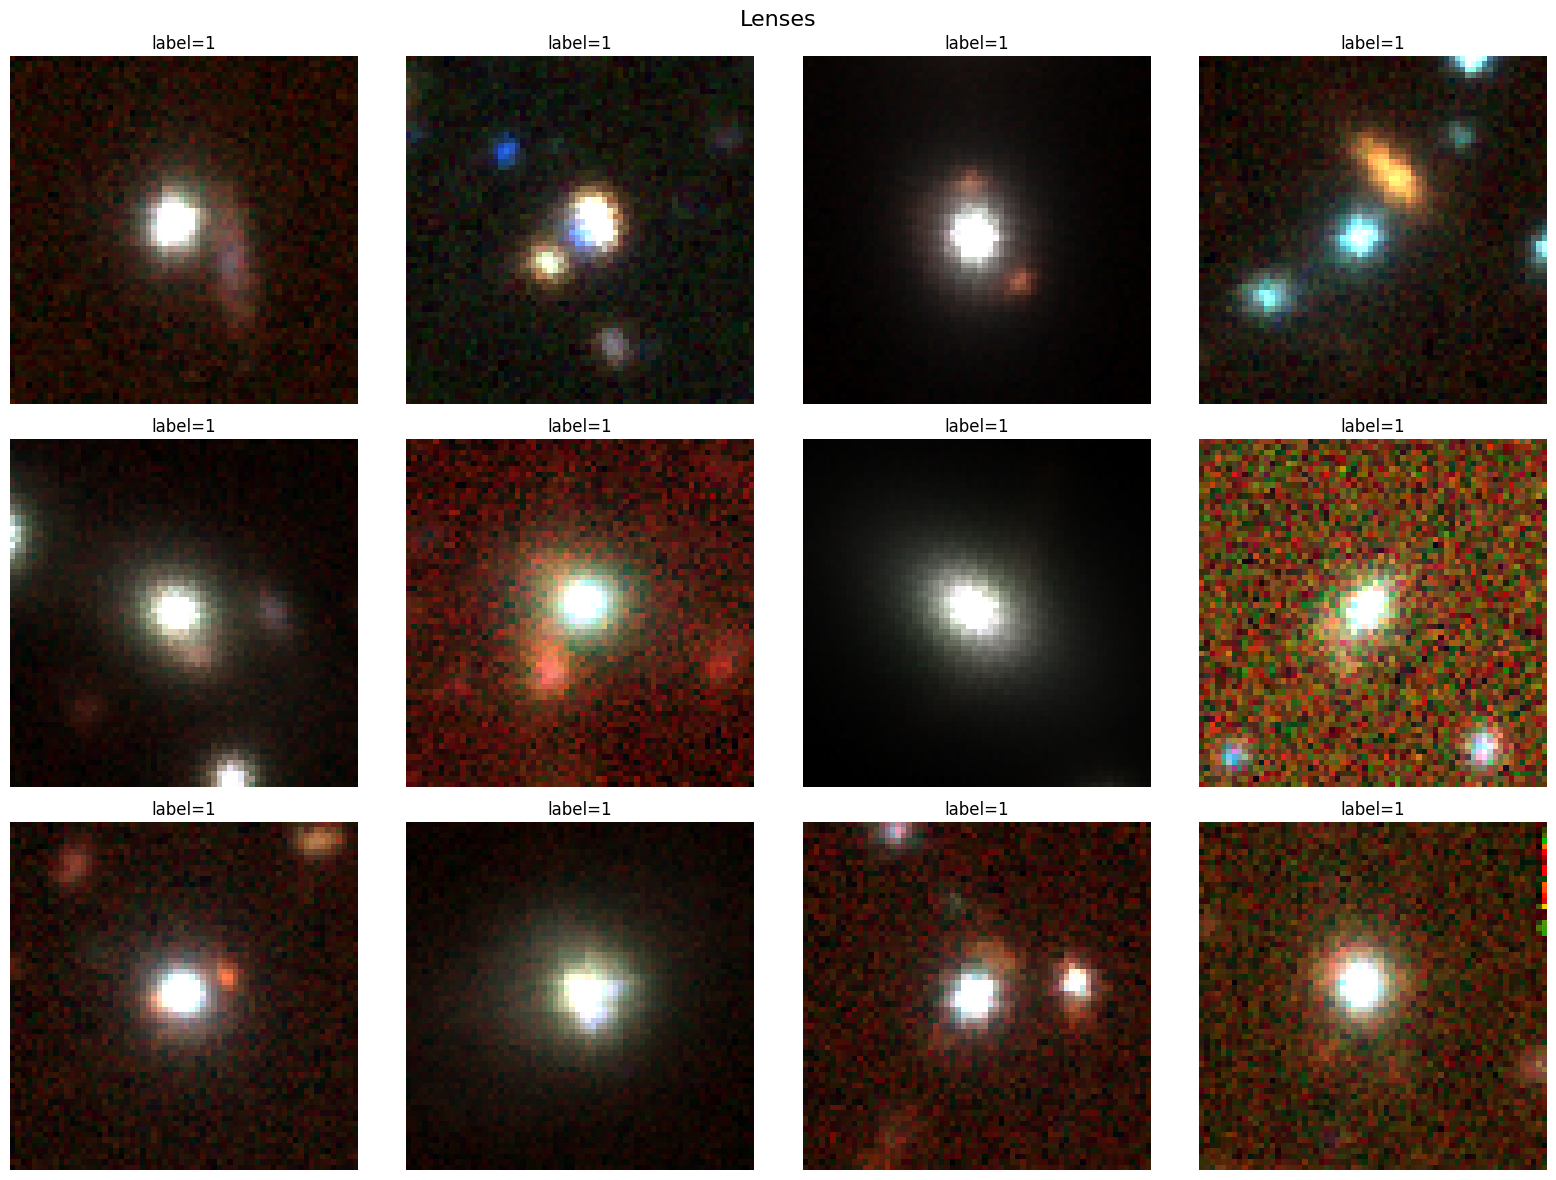

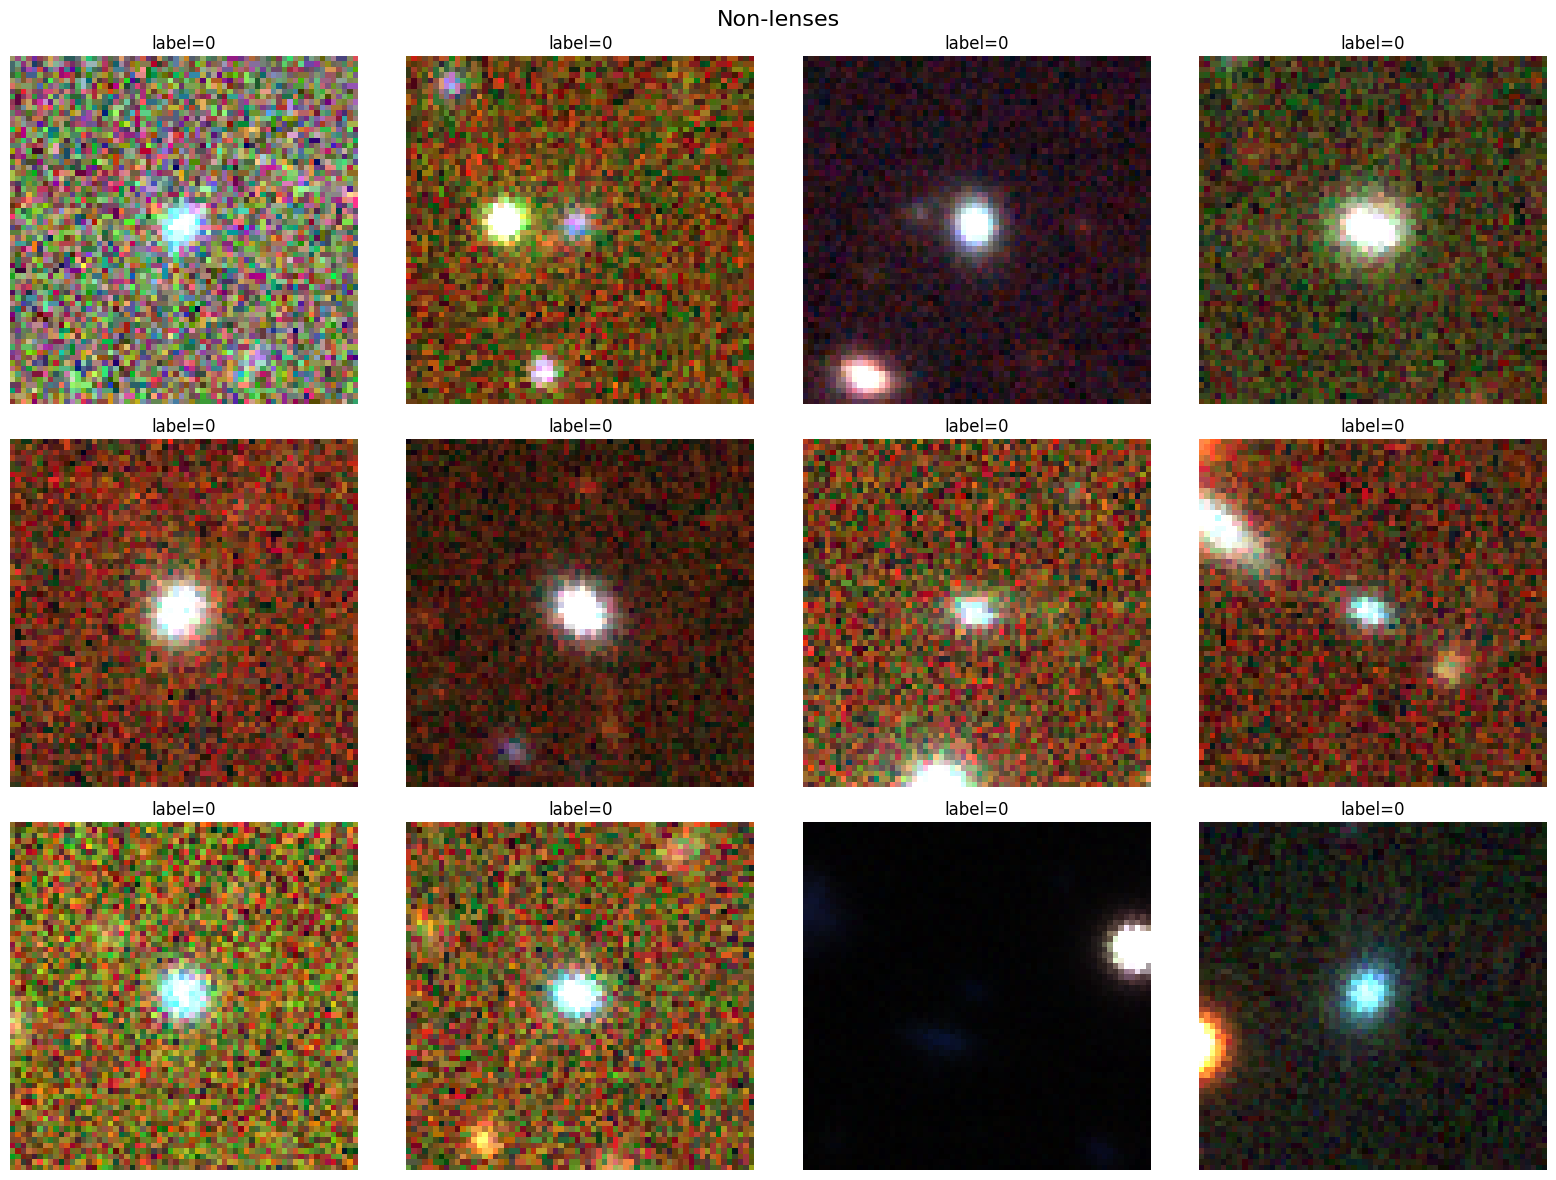

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_lenses/443.npy
label: 1 -> lens
raw: shape=(3, 64, 64) dtype=float32 min=0.000000 max=1.000000 mean=0.154350 std=0.130030
  band 0: min=0.000000 max=1.000000 mean=0.291617 std=0.092383
  band 1: min=0.000000 max=1.000000 mean=0.125654 std=0.084041
  band 2: min=0.000000 max=1.000000 mean=0.045777 std=0.060601
asinh: shape=(3, 64, 64) dtype=float32 min=0.000000 max=1.000000 mean=0.210095 std=0.171388
  band 0: min=0.000000 max=1.000000 mean=0.320480 std=0.165409
  band 1: min=0.000000 max=1.000000 mean=0.184999 std=0.142928
  band 2: min=0.000000 max=1.000000 mean=0.124807 std=0.142283


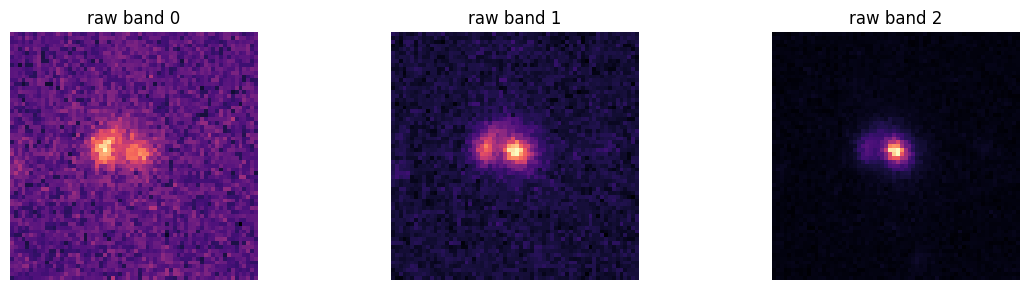

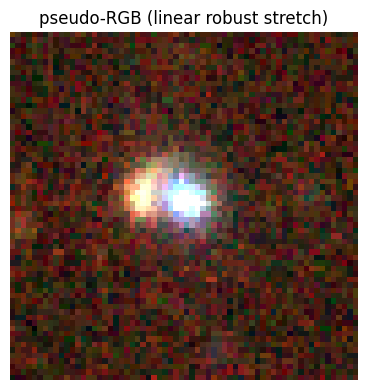

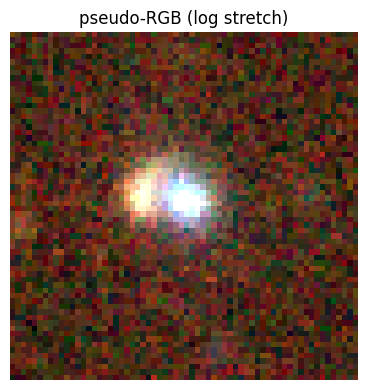

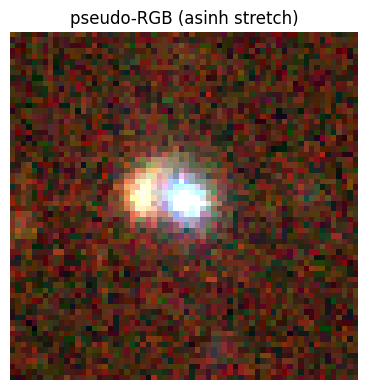

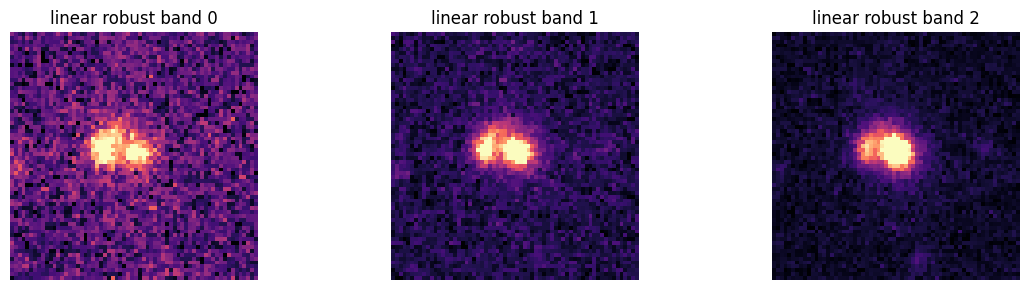

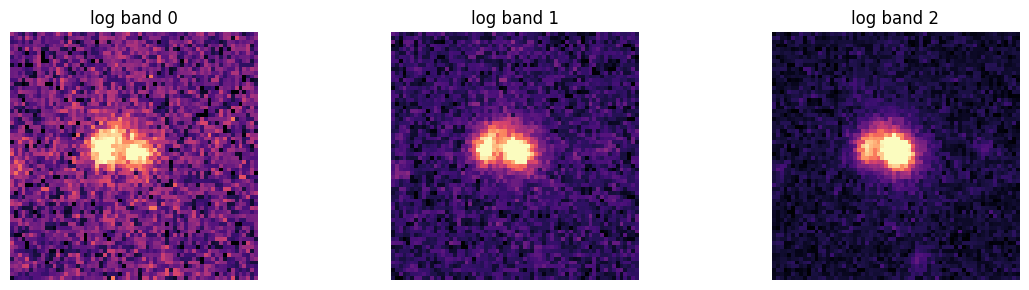

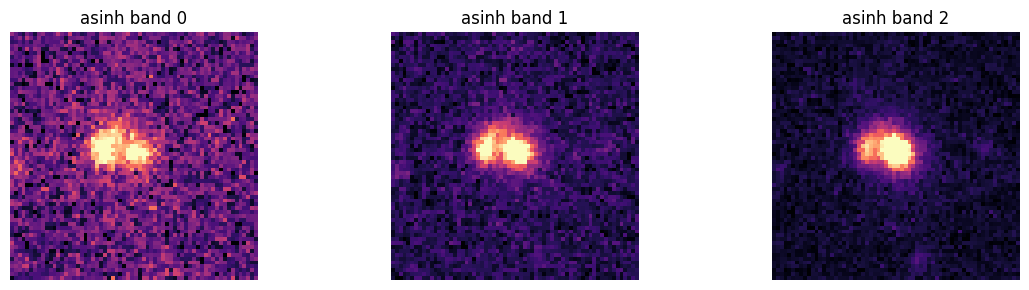

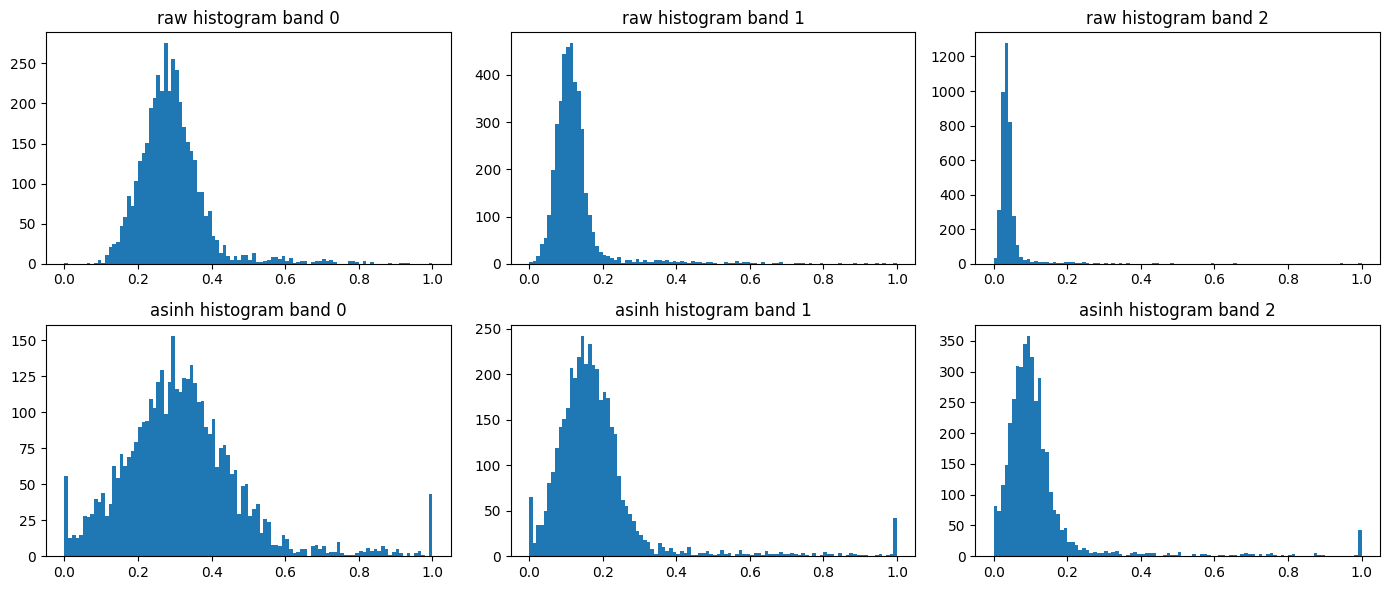

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_lenses/443.npy
label: 1 -> lens


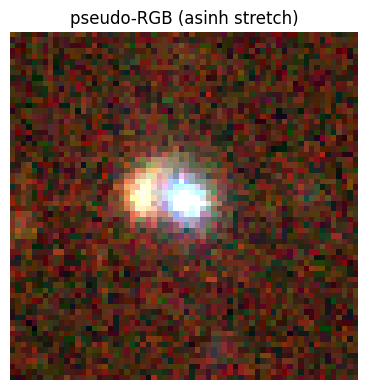

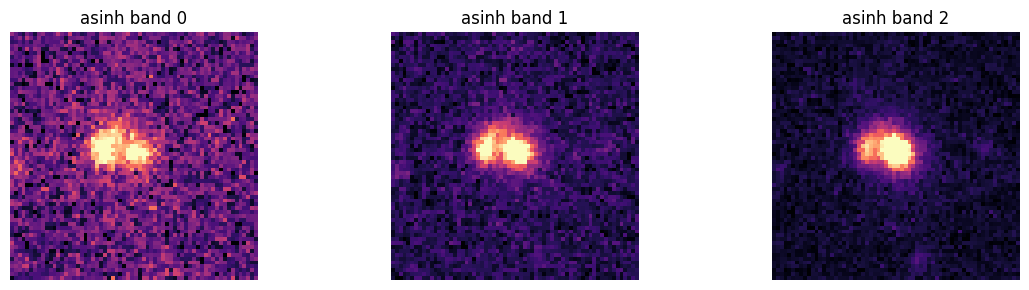

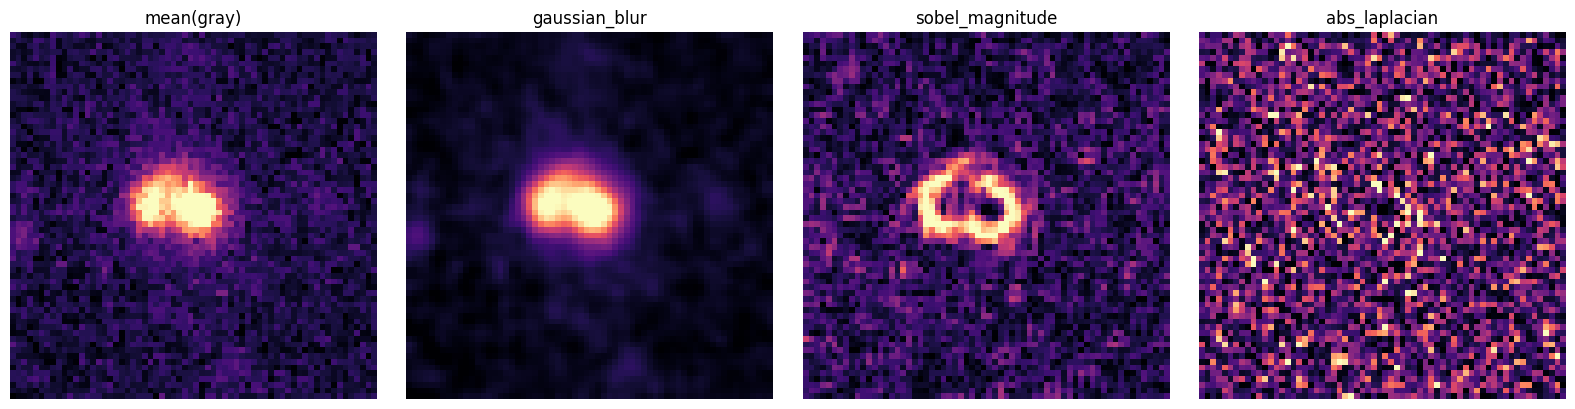

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_lenses/443.npy
label: 1 -> lens


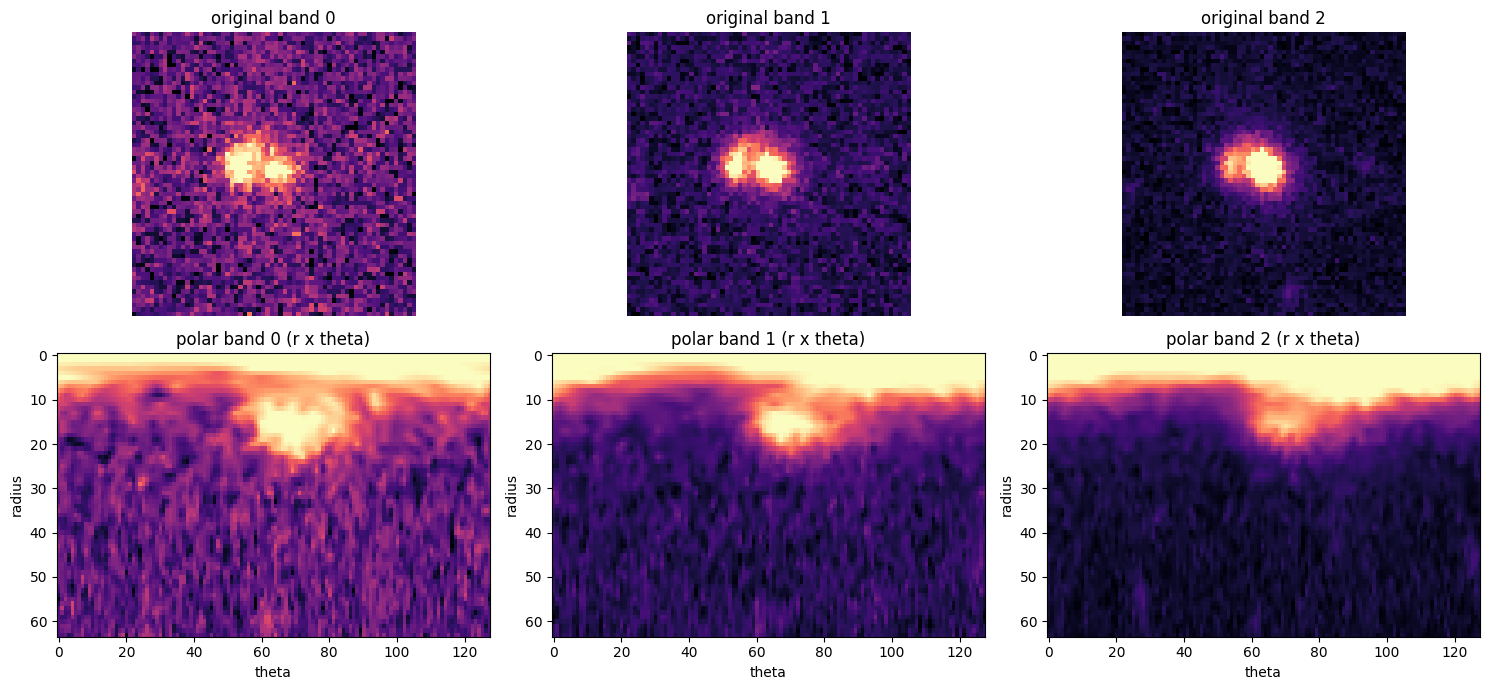

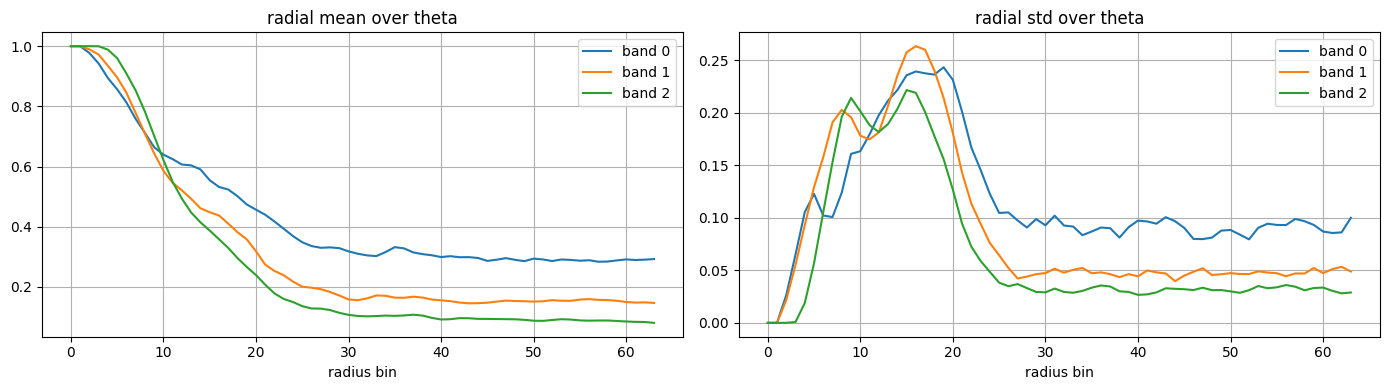

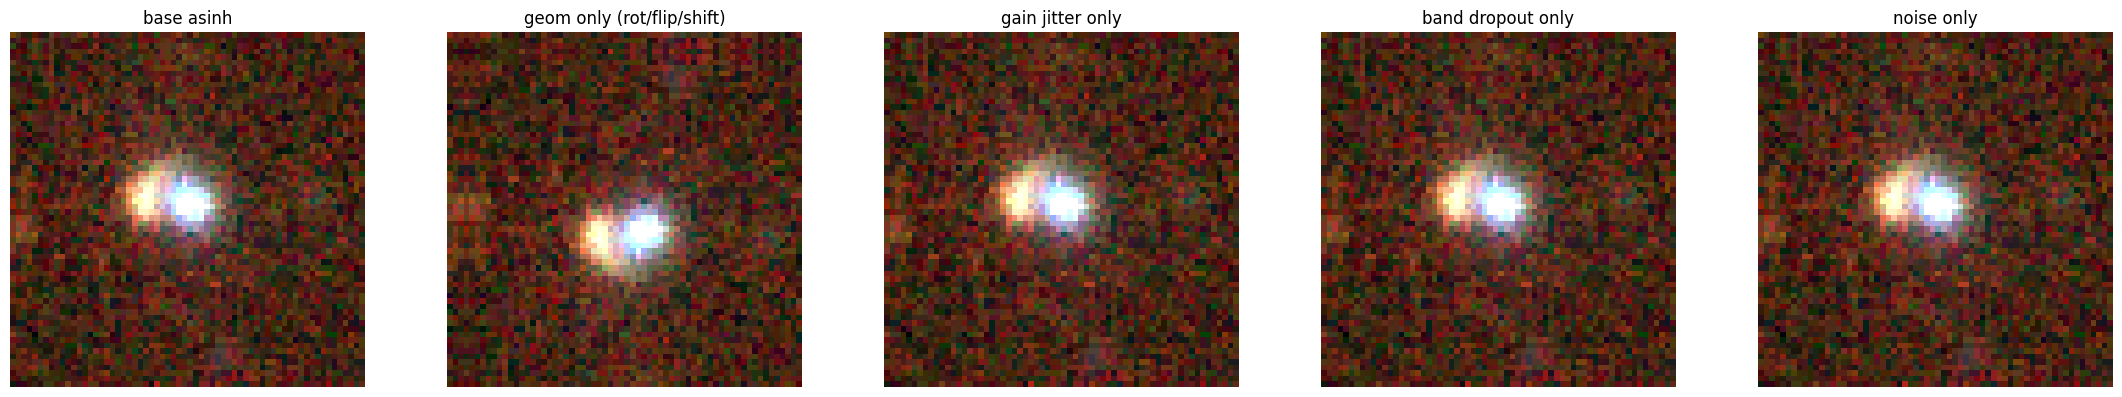

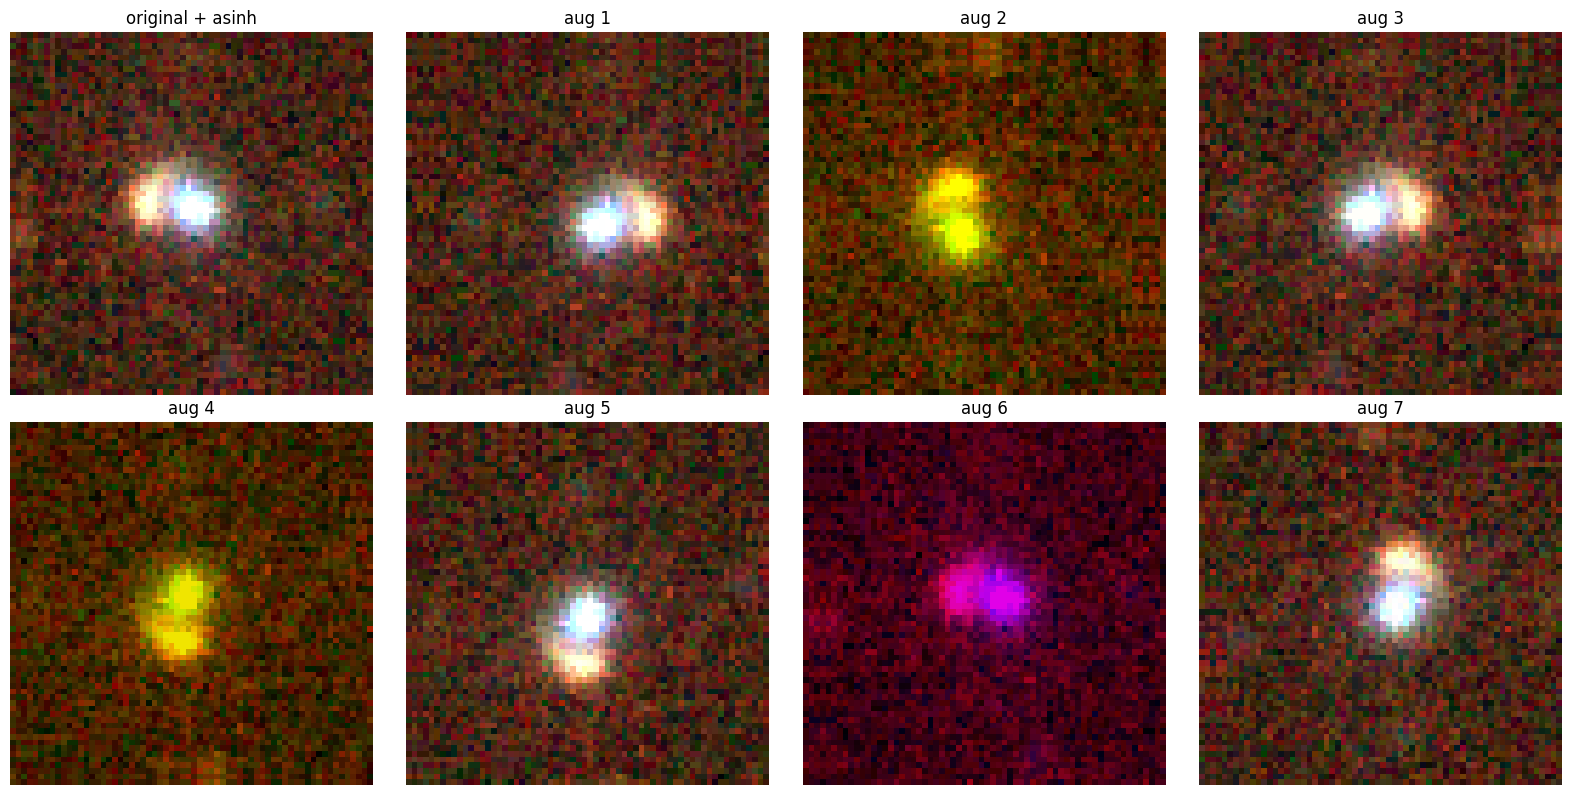

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_nonlenses/13347.npy
label: 0 -> non-lens
raw: shape=(3, 64, 64) dtype=float32 min=0.000000 max=1.000000 mean=0.225589 std=0.128805
  band 0: min=0.000000 max=1.000000 mean=0.353191 std=0.106661
  band 1: min=0.000000 max=1.000000 mean=0.213970 std=0.067611
  band 2: min=0.000000 max=1.000000 mean=0.109607 std=0.062888
asinh: shape=(3, 64, 64) dtype=float32 min=0.000000 max=1.000000 mean=0.384834 std=0.223215
  band 0: min=0.000000 max=1.000000 mean=0.518892 std=0.205799
  band 1: min=0.000000 max=1.000000 mean=0.429147 std=0.192055
  band 2: min=0.000000 max=1.000000 mean=0.206464 std=0.135961


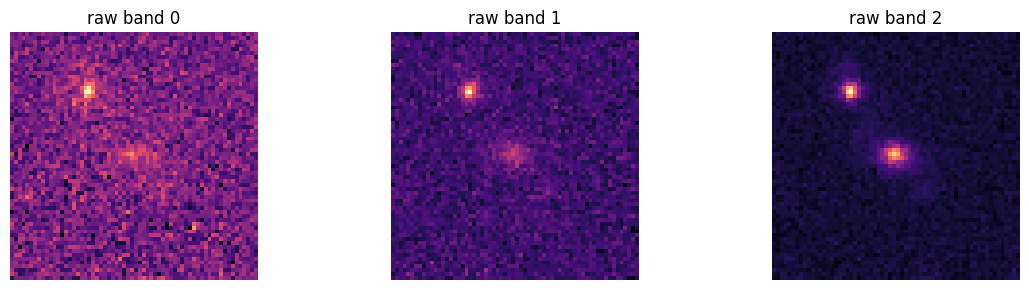

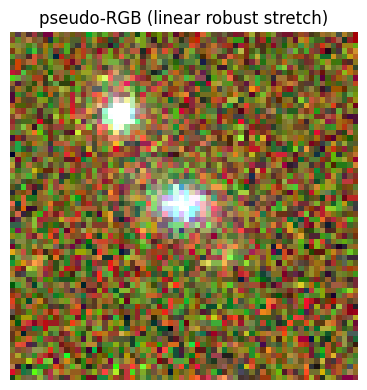

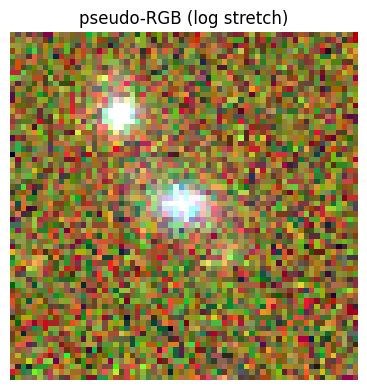

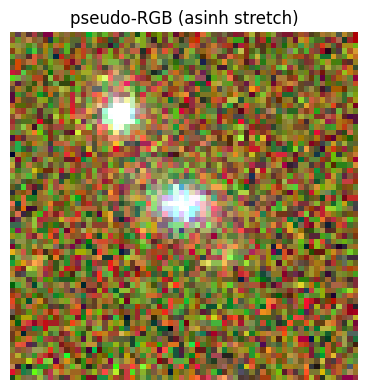

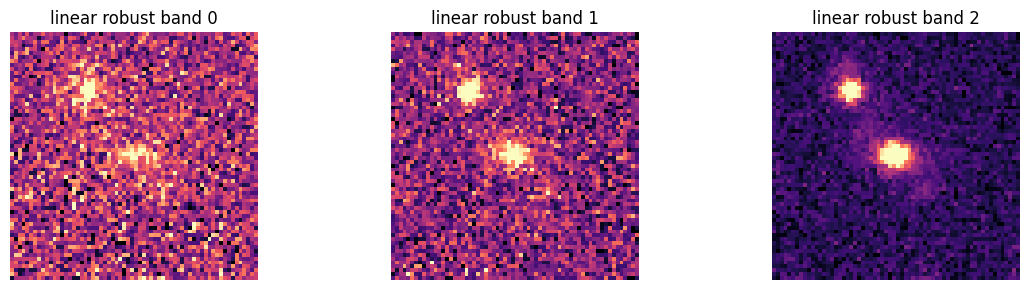

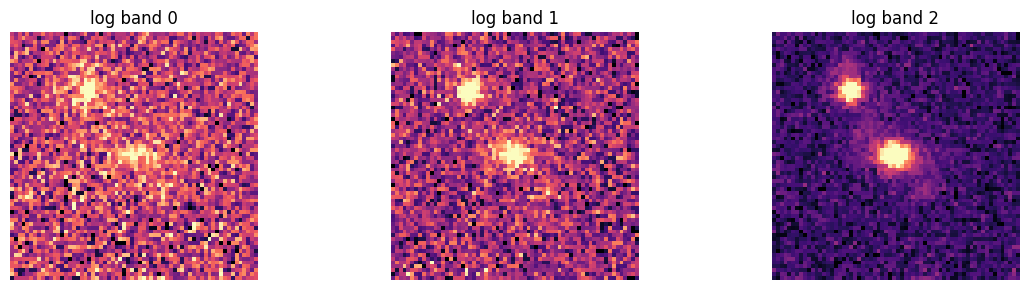

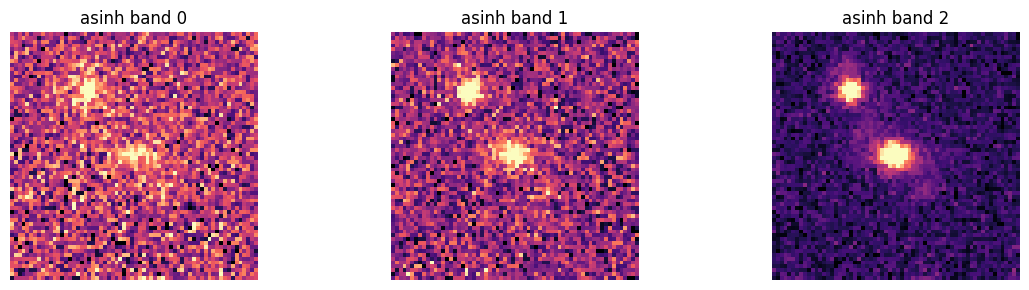

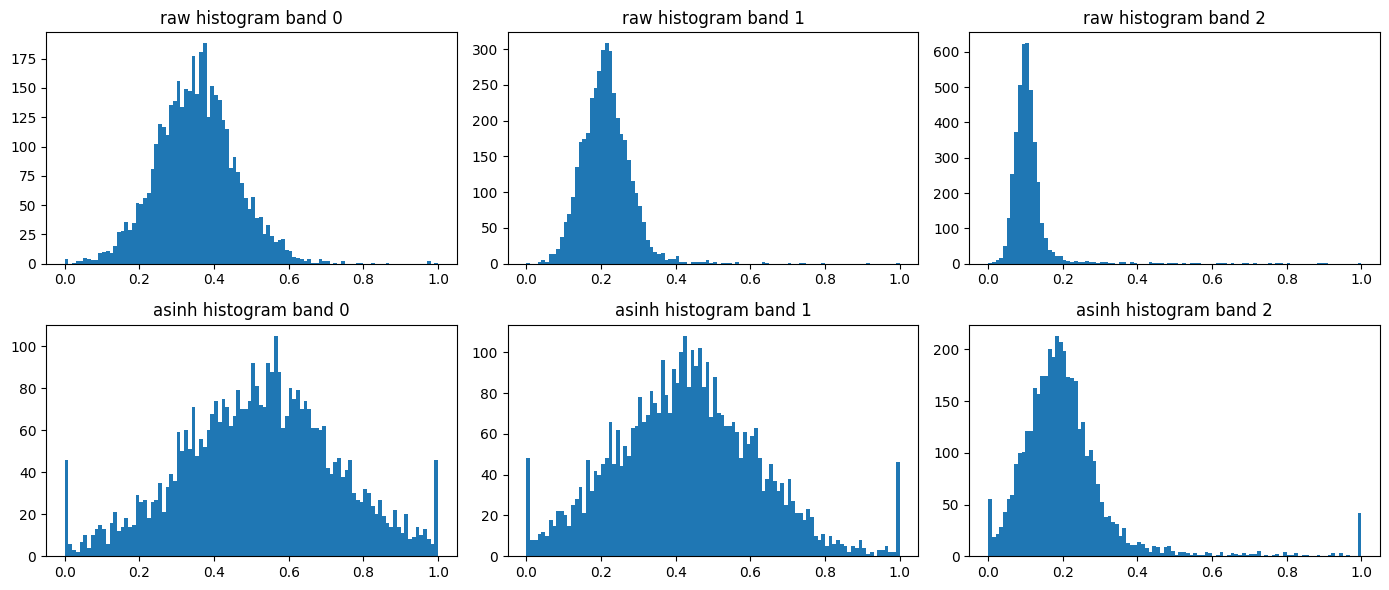

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_nonlenses/13347.npy
label: 0 -> non-lens


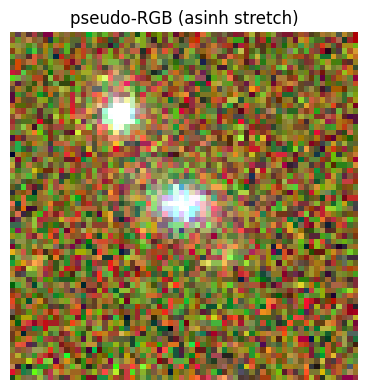

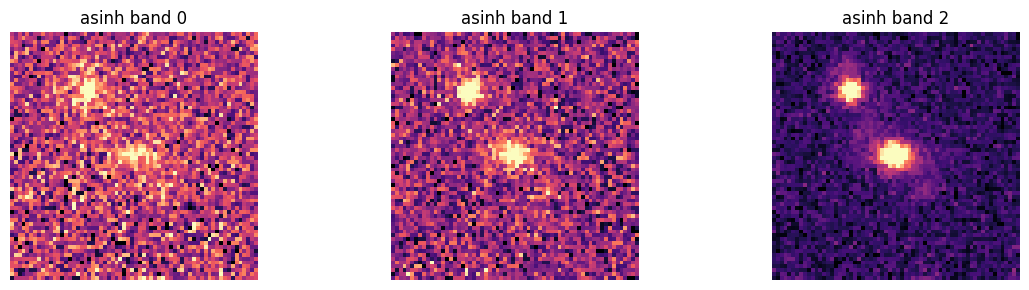

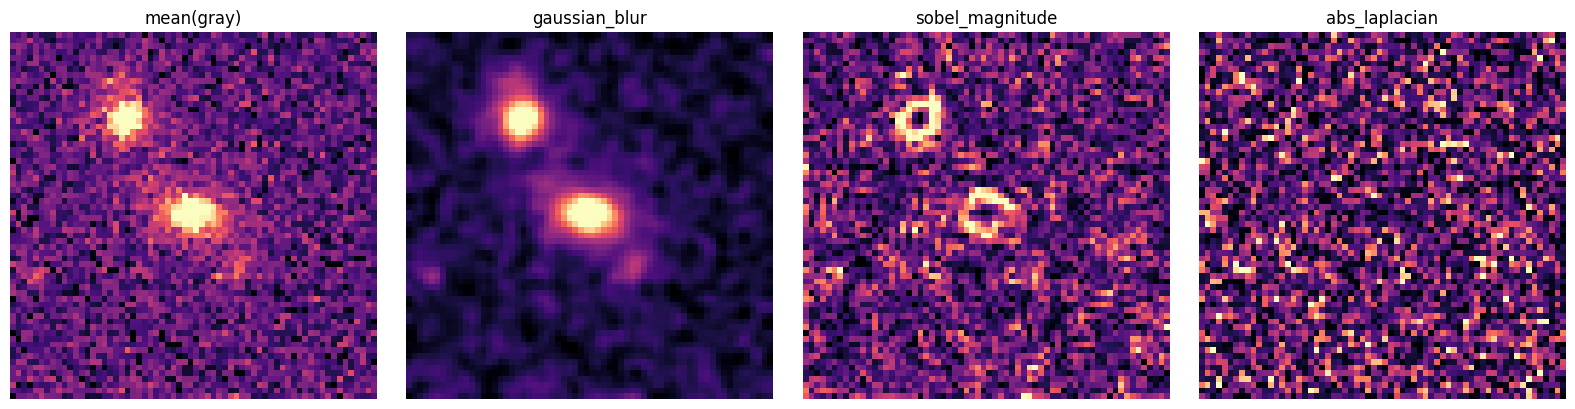

path: /kaggle/input/datasets/arushhh/dataset-task-v/train_nonlenses/13347.npy
label: 0 -> non-lens


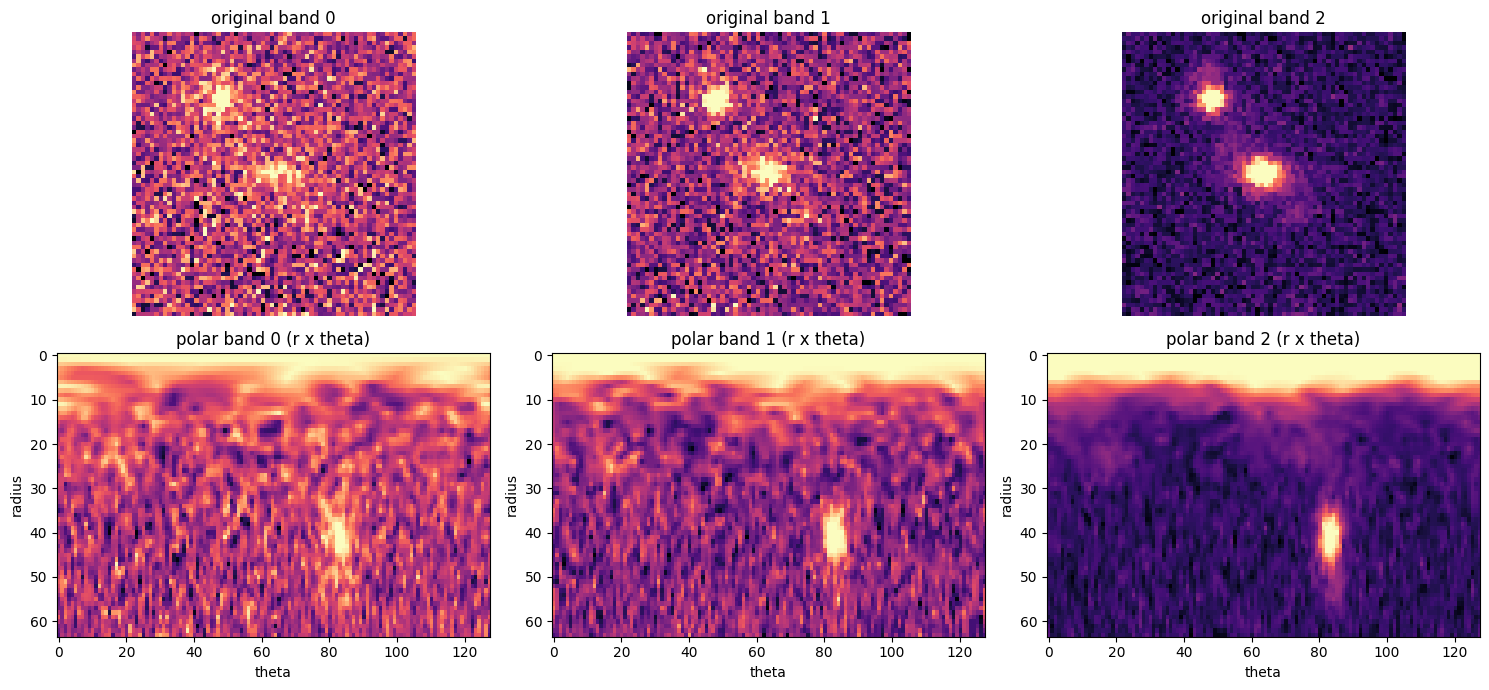

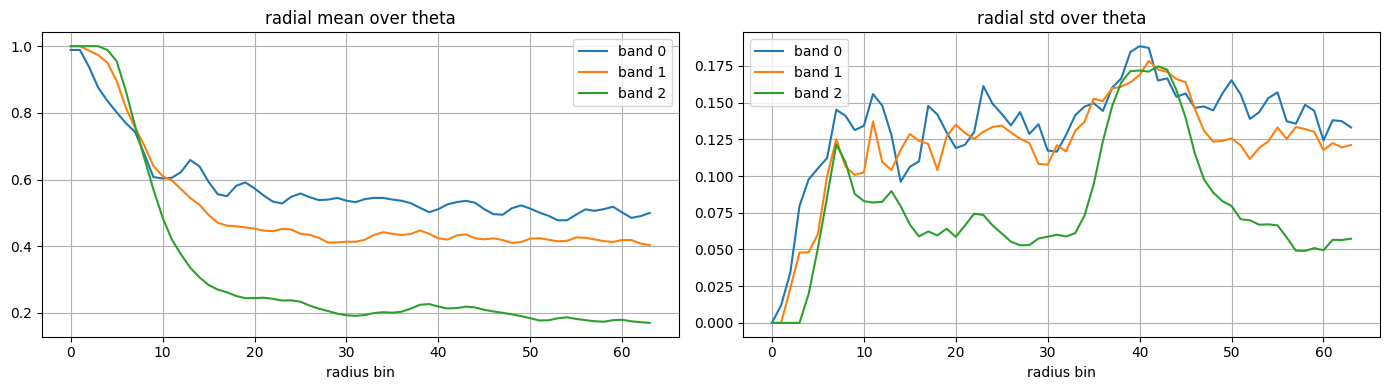

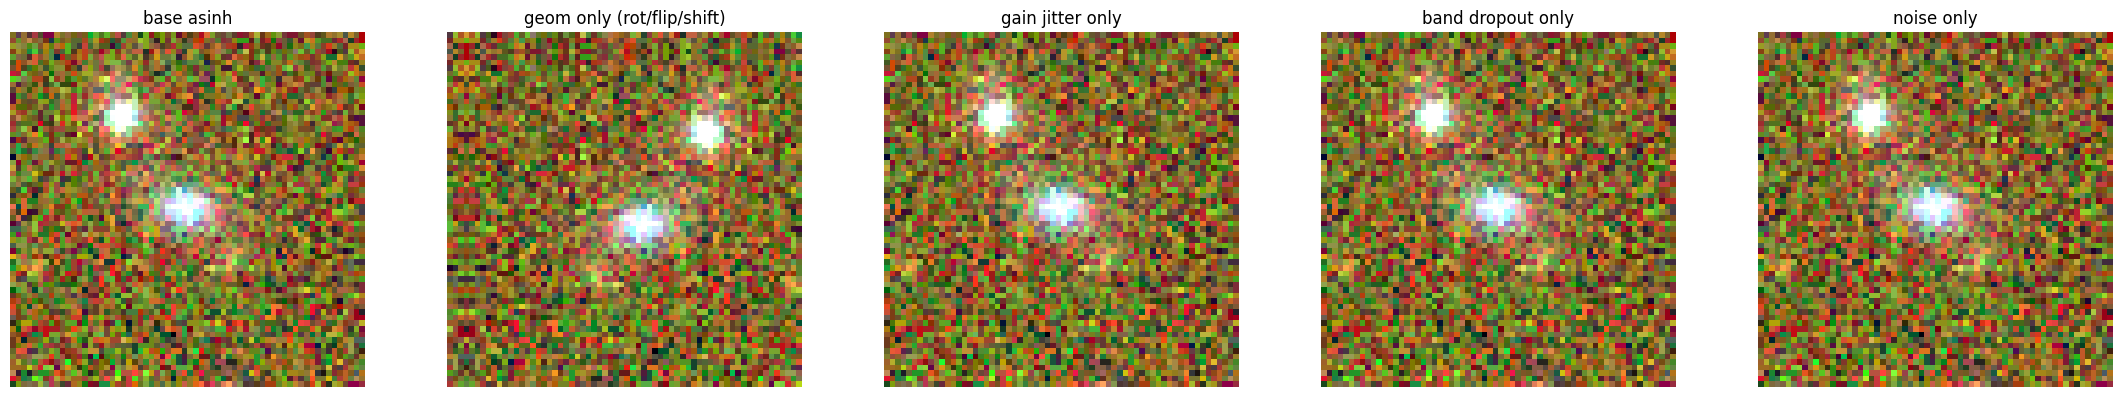

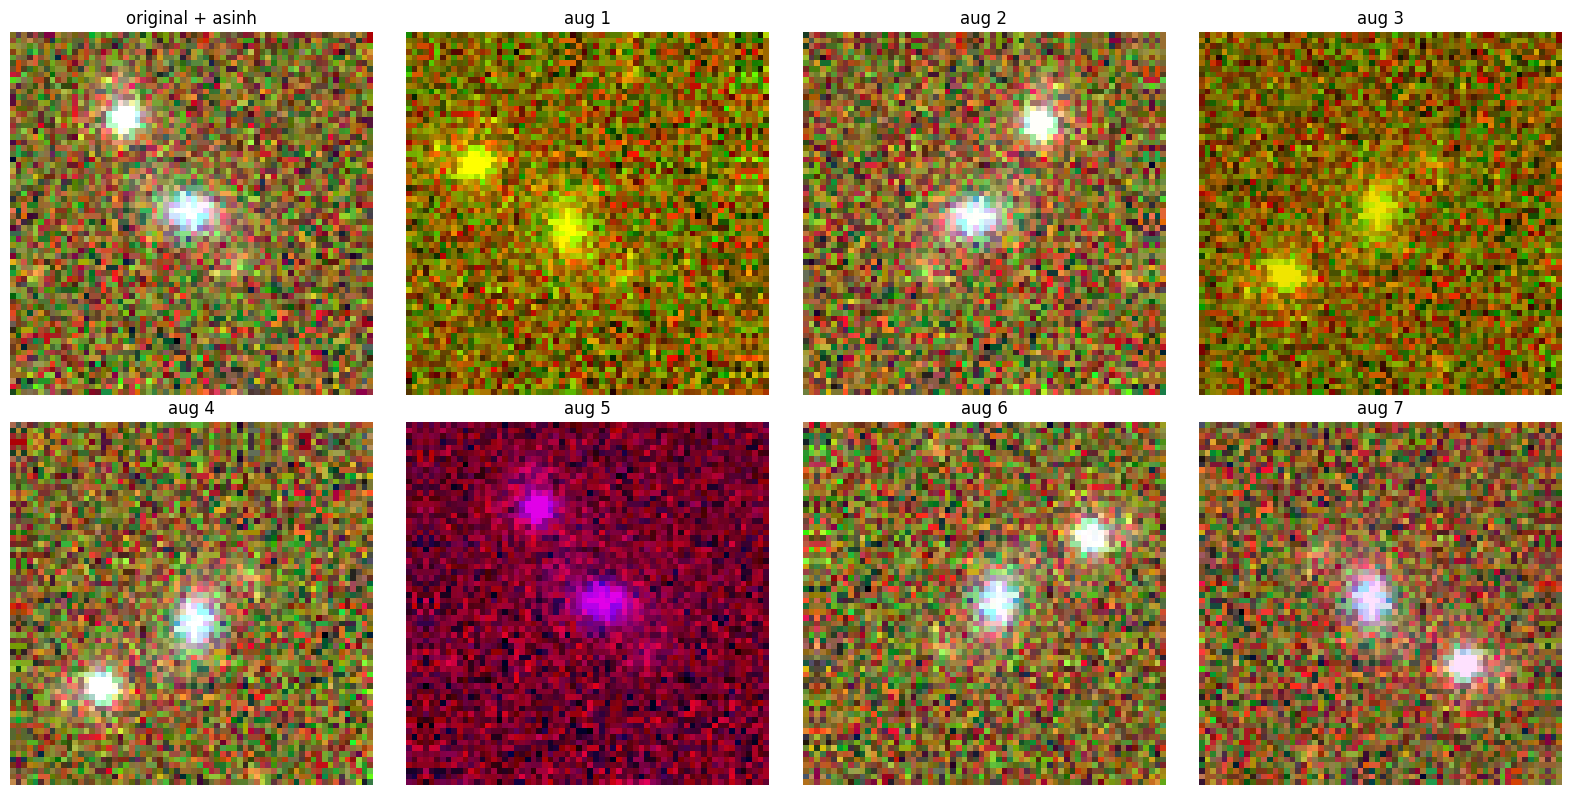

In [20]:
# 1) look at a few positive and negative galleries
show_class_gallery(inspect_df, label=1, n=12, seed=1, title="Lenses")
show_class_gallery(inspect_df, label=0, n=12, seed=2, title="Non-lenses")

# 2) inspect one lens deeply
inspect_sample(inspect_df, label=1, seed=3)
inspect_filters(inspect_df, label=1, seed=3)
inspect_polar_and_radial(inspect_df, label=1, seed=3)
show_each_aug_component(inspect_df, label=1, seed=3)
show_augmentations(inspect_df, label=1, seed=3, n=8)

# 3) inspect one non-lens deeply
inspect_sample(inspect_df, label=0, seed=4)
inspect_filters(inspect_df, label=0, seed=4)
inspect_polar_and_radial(inspect_df, label=0, seed=4)
show_each_aug_component(inspect_df, label=0, seed=4)
show_augmentations(inspect_df, label=0, seed=4, n=8)